# Segmentación de Clientes Bancarios

**Curso:** Análisis de Datos Avanzados  
**Estudiante:** Eriksson Hernández  
**Dataset:** `bank-additional-full.csv`  
**Variable objetivo:** `y`  
**Métodos de segmentación:** K-Means y Clustering Jerárquico con enlace Ward

## Propósito del notebook

Este notebook constituye el entregable principal de análisis. El diseño prioriza cuatro objetivos:

1. **Rigor metodológico**, justificando cada decisión estadística y técnica.
2. **Legibilidad ejecutiva**, integrando narrativa analítica en formato markdown.
3. **Reproducibilidad**, apoyándose en módulos auxiliares dentro de `src/`.
4. **Trazabilidad**, dejando visibles los resultados, tablas y gráficas una vez que el notebook sea ejecutado.

## Problema de negocio

La institución financiera desea comprender el comportamiento de sus clientes antes de una campaña de marketing telefónico orientada a la suscripción de depósitos a plazo. Desde una perspectiva analítica, esto implica identificar patrones de comportamiento, construir segmentos homogéneos y evaluar si dichos segmentos presentan diferencias relevantes frente a la variable objetivo `y`.

## Decisiones metodológicas clave

- La variable `duration` será **excluida del clustering**. La razón es metodológica: su valor solo es conocido después de que la llamada ocurre, por lo que introducirla en una segmentación previa a la campaña produciría fuga de información.
- Los valores `unknown` no se eliminan de manera automática. Se interpretan como una señal de calidad de dato o de ausencia informativa potencialmente relevante.
- El notebook utiliza una arquitectura híbrida: la **narrativa y la orquestación viven aquí**, mientras que las funciones reutilizables se mantienen en `src/` para evitar duplicación y conservar clean code.

## 1. Importación de librerías y configuración del entorno

Esta sección centraliza dependencias, configuración visual y carga de funciones auxiliares.  
El objetivo es que el resto del notebook sea claro, breve y fácil de mantener.

In [34]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import silhouette_score

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    CATEGORY_PLOTS_FIGSIZE,
    CLUSTER_PLOTS_FIGSIZE,
    CORRELATION_FIGSIZE,
    DATA_PATH,
    DAY_ORDER,
    DENDROGRAM_SAMPLE_SIZE,
    HIERARCHICAL_SAMPLE_SIZE,
    K_RANGE,
    MONTH_ORDER,
    PCA_COMPONENTS_FOR_CLUSTERING,
    PCA_FIGSIZE,
    RANDOM_STATE,
    TARGET_COLUMN,
    TOP_CATEGORY_LEVELS,
)
from src.data_utils import (
    build_clustering_dataset,
    get_variable_types,
    load_bank_data,
    profiling_report,
    summarize_categorical,
    summarize_numeric,
)
from src.eda_utils import (
    conversion_rate_by_category,
    iqr_outlier_summary,
    numeric_summary_by_target,
    redundancy_pairs,
    zscore_outlier_summary,
)
from src.clustering_utils import (
    business_segment_name,
    cluster_profile,
    evaluate_kmeans_range,
    fit_hierarchical,
    fit_kmeans,
    fit_pca,
    hierarchical_linkage_matrix,
    select_best_k,
    transform_features,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 2. Carga de datos y entendimiento inicial

Primero se carga el dataset y se identifican los tipos de variables. Esta lectura inicial permite responder preguntas básicas pero fundamentales:

- ¿Cuántos registros y columnas tiene el dataset?
- ¿Qué variables son numéricas y cuáles categóricas?
- ¿La estructura coincide con lo esperado según la documentación?

In [35]:
df = load_bank_data(csv_path=str(DATA_PATH))
numeric_columns, categorical_columns = get_variable_types(df, target_column=TARGET_COLUMN)

print(f"Dimensiones del dataset: {df.shape[0]:,} filas y {df.shape[1]} columnas")
print("\nVariables numéricas:")
print(numeric_columns)
print("\nVariables categóricas:")
print(categorical_columns)

display(df.head())

Dimensiones del dataset: 41,188 filas y 21 columnas

Variables numéricas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no


### Observación analítica

En este punto conviene confirmar que la variable objetivo `y` no será usada como insumo para clustering, sino como referencia posterior para interpretar el valor de negocio de cada segmento.

## 3. Profiling y calidad de datos

El profiling permite cuantificar problemas estructurales del dataset: valores faltantes, cardinalidad, tipos de dato y presencia de la categoría `unknown`.

Este paso es indispensable porque una segmentación útil depende tanto de la técnica como de la calidad de la información.

In [36]:
quality_report = profiling_report(df)
quality_report

,dtype,missing_values,missing_rate,unique_values,unknown_values,unknown_rate
age,int64,0,0.0000,78,0,0.0000
job,str,0,0.0000,12,0,0.0000
marital,str,0,0.0000,4,0,0.0000
education,str,0,0.0000,8,0,0.0000
default,str,0,0.0000,3,0,0.0000
housing,str,0,0.0000,3,0,0.0000
loan,str,0,0.0000,3,0,0.0000
contact,str,0,0.0000,2,0,0.0000
month,str,0,0.0000,10,0,0.0000
day_of_week,str,0,0.0000,5,0,0.0000


### Lectura esperada del profiling

Al analizar esta tabla se deben identificar, como mínimo, los siguientes aspectos:

- variables con alto uso de `unknown`,
- variables con posible baja utilidad por escasa variabilidad,
- y posibles decisiones de transformación antes del clustering.

En este dataset, la ausencia de nulos explícitos no implica ausencia de problemas de calidad, porque parte de la información faltante está codificada como texto.

## 4. Análisis exploratorio de datos

La exploración se divide en tres niveles complementarios:

1. **Análisis univariado**, para entender cada variable de forma aislada.
2. **Análisis bivariado**, para estudiar relaciones con la variable objetivo y entre variables.
3. **Análisis multivariado**, para evaluar estructura global, redundancia y reducción de dimensionalidad.

## 4.1 Análisis univariado de variables numéricas

Se estudian medidas descriptivas, dispersión, forma de la distribución y presencia de outliers.  
Esto es relevante porque muchos algoritmos de clustering son sensibles a escala, sesgo y valores extremos.

In [37]:
numeric_summary = summarize_numeric(df, numeric_columns)
numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,"41,188.0000",40.0241,10.4212,17.0000,32.0000,38.0000,47.0000,98.0000
duration,"41,188.0000",258.2850,259.2792,0.0000,102.0000,180.0000,319.0000,"4,918.0000"
campaign,"41,188.0000",2.5676,2.7700,1.0000,1.0000,2.0000,3.0000,56.0000
pdays,"41,188.0000",962.4755,186.9109,0.0000,999.0000,999.0000,999.0000,999.0000
previous,"41,188.0000",0.1730,0.4949,0.0000,0.0000,0.0000,0.0000,7.0000
emp.var.rate,"41,188.0000",0.0819,1.5710,-3.4000,-1.8000,1.1000,1.4000,1.4000
cons.price.idx,"41,188.0000",93.5757,0.5788,92.2010,93.0750,93.7490,93.9940,94.7670
cons.conf.idx,"41,188.0000",-40.5026,4.6282,-50.8000,-42.7000,-41.8000,-36.4000,-26.9000
euribor3m,"41,188.0000",3.6213,1.7344,0.6340,1.3440,4.8570,4.9610,5.0450
nr.employed,"41,188.0000","5,167.0359",72.2515,"4,963.6000","5,099.1000","5,191.0000","5,228.1000","5,228.1000"


In [38]:
iqr_summary = iqr_outlier_summary(df, numeric_columns=numeric_columns)
zscore_summary = zscore_outlier_summary(df, numeric_columns=numeric_columns)

print("Resumen de outliers por criterio IQR")
display(iqr_summary)

print("Resumen de outliers por criterio Z-Score")
display(zscore_summary)

Resumen de outliers por criterio IQR


,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
4,previous,0.0000,0.0000,0.0000,0.0000,0.0000,5625,0.1366
1,duration,102.0000,319.0000,217.0000,-223.5000,644.5000,2963,0.0719
2,campaign,1.0000,3.0000,2.0000,-2.0000,6.0000,2406,0.0584
3,pdays,999.0000,999.0000,0.0000,999.0000,999.0000,1515,0.0368
0,age,32.0000,47.0000,15.0000,9.5000,69.5000,469,0.0114
7,cons.conf.idx,-42.7000,-36.4000,6.3000,-52.1500,-26.9500,447,0.0109
5,emp.var.rate,-1.8000,1.4000,3.2000,-6.6000,6.2000,0,0.0000
6,cons.price.idx,93.0750,93.9940,0.9190,91.6965,95.3725,0,0.0000
8,euribor3m,1.3440,4.9610,3.6170,-4.0815,10.3865,0,0.0000
9,nr.employed,"5,099.1000","5,228.1000",129.0000,"4,905.6000","5,421.6000",0,0.0000


Resumen de outliers por criterio Z-Score


,variable,z_threshold,outlier_count,outlier_rate
3,pdays,3.0000,1515,0.0368
4,previous,3.0000,1064,0.0258
2,campaign,3.0000,869,0.0211
1,duration,3.0000,861,0.0209
0,age,3.0000,369,0.0090
5,emp.var.rate,3.0000,0,0.0000
6,cons.price.idx,3.0000,0,0.0000
7,cons.conf.idx,3.0000,0,0.0000
8,euribor3m,3.0000,0,0.0000
9,nr.employed,3.0000,0,0.0000


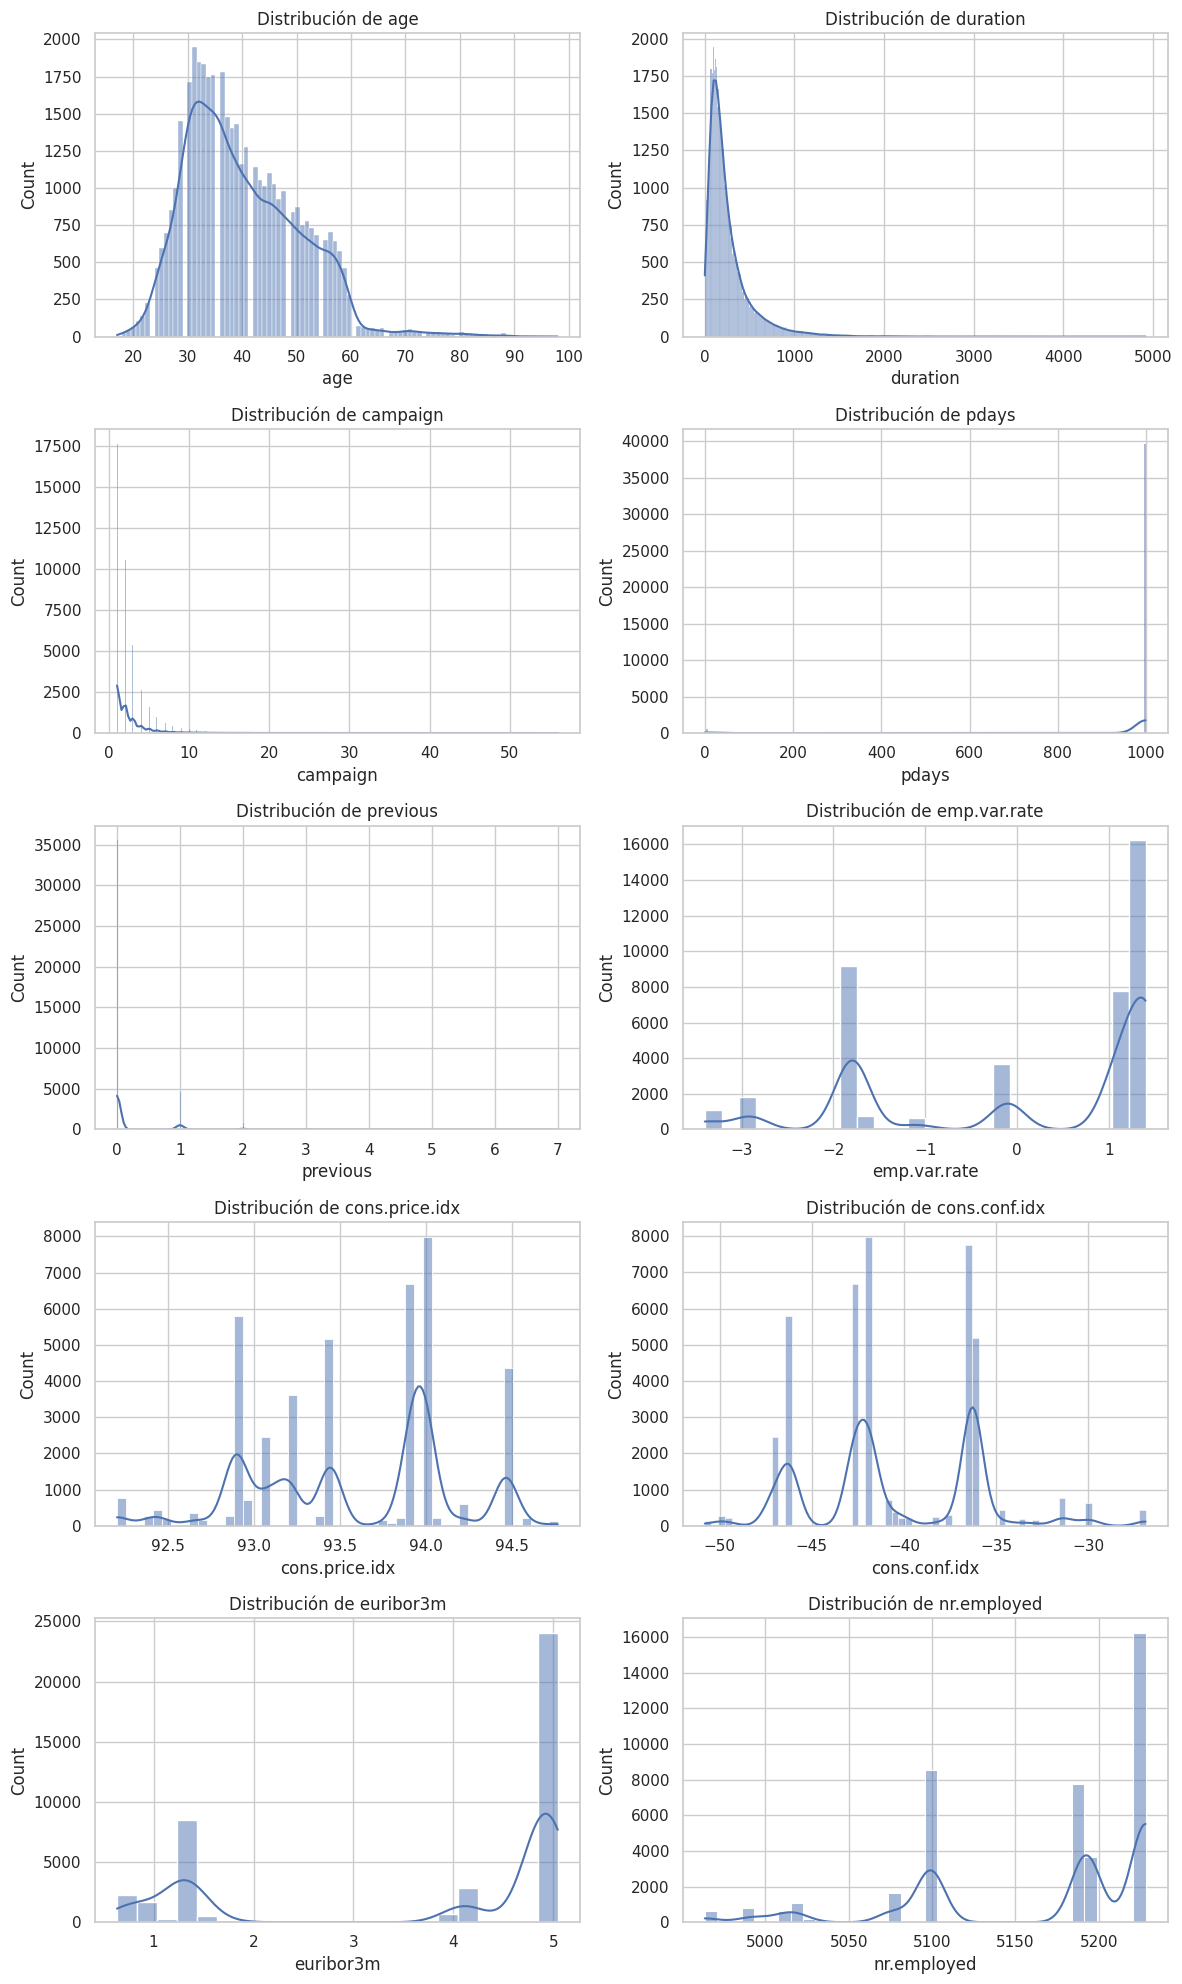

In [39]:
n_numeric = len(numeric_columns)
n_cols = 2
n_rows = int(np.ceil(n_numeric / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for axis, column in zip(axes, numeric_columns):
    sns.histplot(data=df, x=column, kde=True, ax=axis)
    axis.set_title(f"Distribución de {column}")

for axis in axes[n_numeric:]:
    axis.axis("off")

plt.tight_layout()
plt.show()

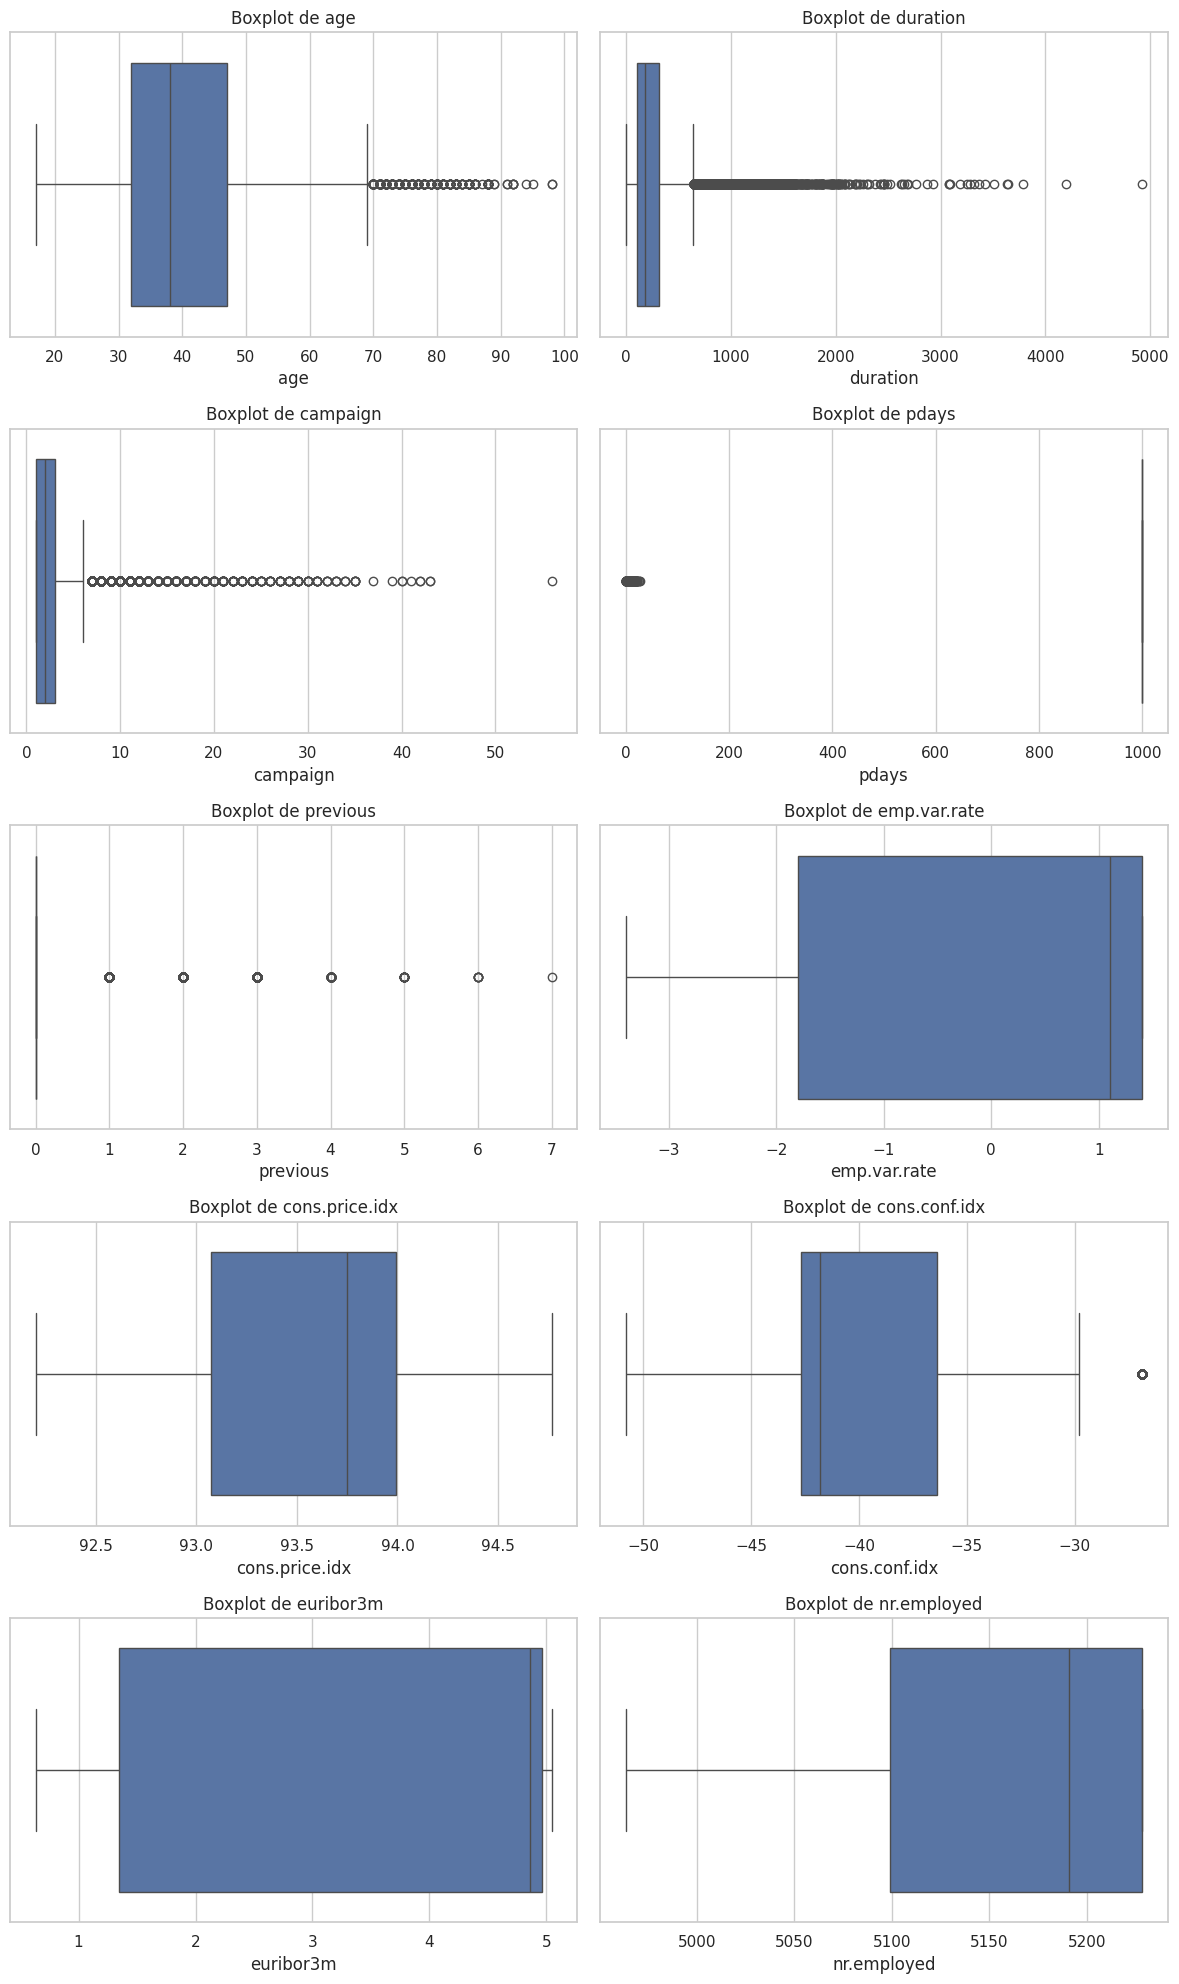

In [40]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for axis, column in zip(axes, numeric_columns):
    sns.boxplot(data=df, x=column, ax=axis)
    axis.set_title(f"Boxplot de {column}")

for axis in axes[n_numeric:]:
    axis.axis("off")

plt.tight_layout()
plt.show()

### Interpretación sugerida

Aquí no basta con señalar que una variable tiene outliers.  
La discusión debe explicar si esos valores extremos:

- parecen plausibles dentro del contexto bancario,
- pueden distorsionar la distancia entre observaciones,
- y justifican la necesidad de escalamiento antes del clustering.

## 4.2 Análisis univariado de variables categóricas

En esta subsección interesa conocer:

- categorías dominantes,
- cardinalidad efectiva,
- y presencia de `unknown`.

El objetivo es detectar patrones de composición del portafolio de clientes y evaluar la complejidad de codificación posterior.

In [41]:
categorical_summaries = summarize_categorical(df, categorical_columns)

for column in categorical_columns:
    print(f"Frecuencias para {column}")
    display(categorical_summaries[column].head(TOP_CATEGORY_LEVELS))

Frecuencias para job


,job,count,proportion
0,admin.,10422,0.2530
1,blue-collar,9254,0.2247
2,technician,6743,0.1637
3,services,3969,0.0964
4,management,2924,0.0710
5,retired,1720,0.0418
6,entrepreneur,1456,0.0354
7,self-employed,1421,0.0345
8,housemaid,1060,0.0257
9,unemployed,1014,0.0246


Frecuencias para marital


,marital,count,proportion
0,married,24928,0.6052
1,single,11568,0.2809
2,divorced,4612,0.1120
3,unknown,80,0.0019


Frecuencias para education


...

,month,count,proportion
0,may,13769,0.3343
1,jul,7174,0.1742
2,aug,6178,0.1500
3,jun,5318,0.1291
4,nov,4101,0.0996
5,apr,2632,0.0639
6,oct,718,0.0174
7,sep,570,0.0138
8,mar,546,0.0133
9,dec,182,0.0044


Frecuencias para day_of_week


,day_of_week,count,proportion
0,thu,8623,0.2094
1,mon,8514,0.2067
2,wed,8134,0.1975
3,tue,8090,0.1964
4,fri,7827,0.1900


Frecuencias para poutcome


,poutcome,count,proportion
0,nonexistent,35563,0.8634
1,failure,4252,0.1032
2,success,1373,0.0333


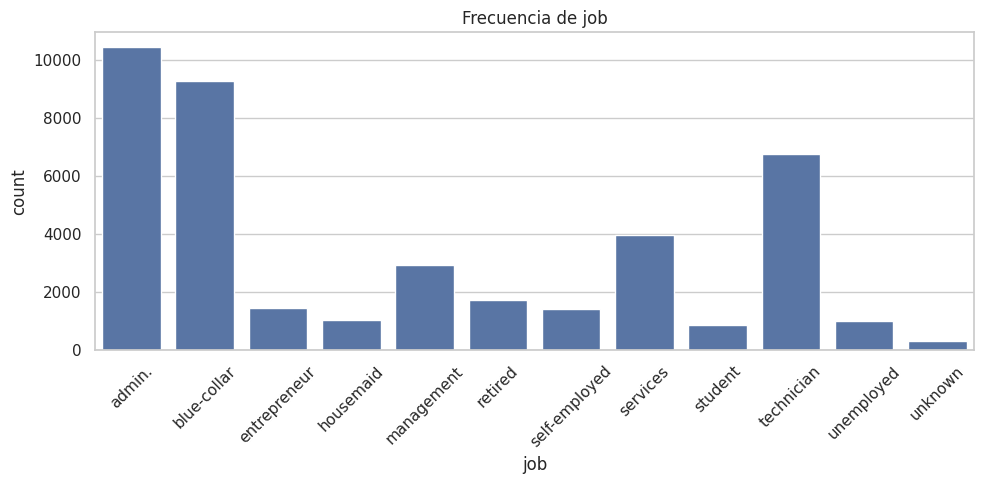

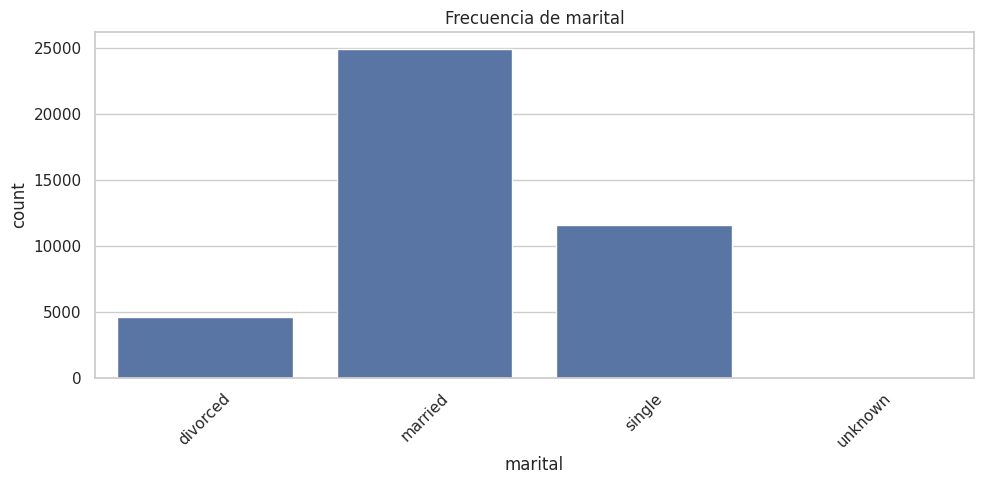

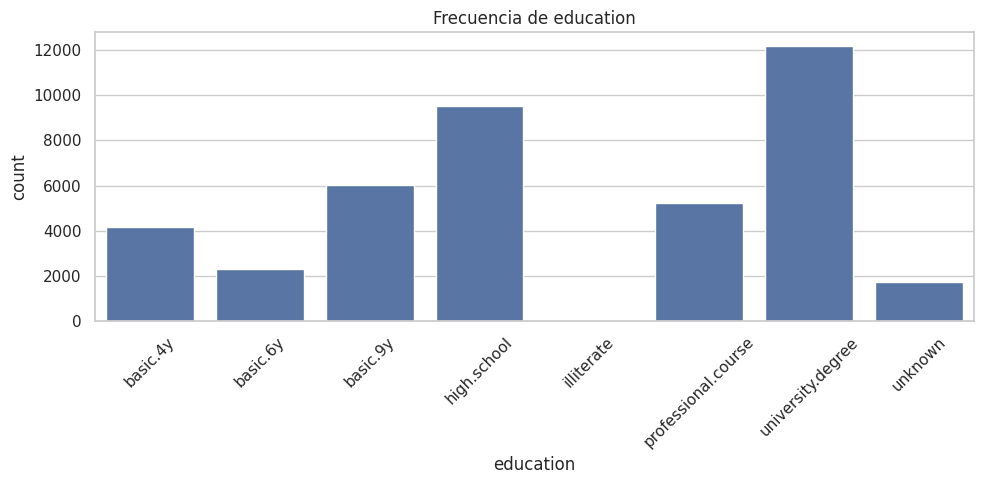

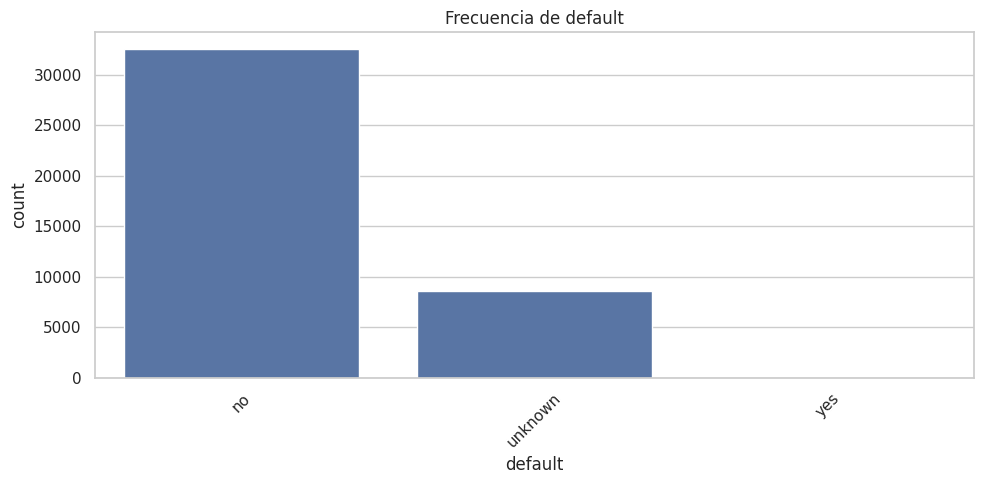

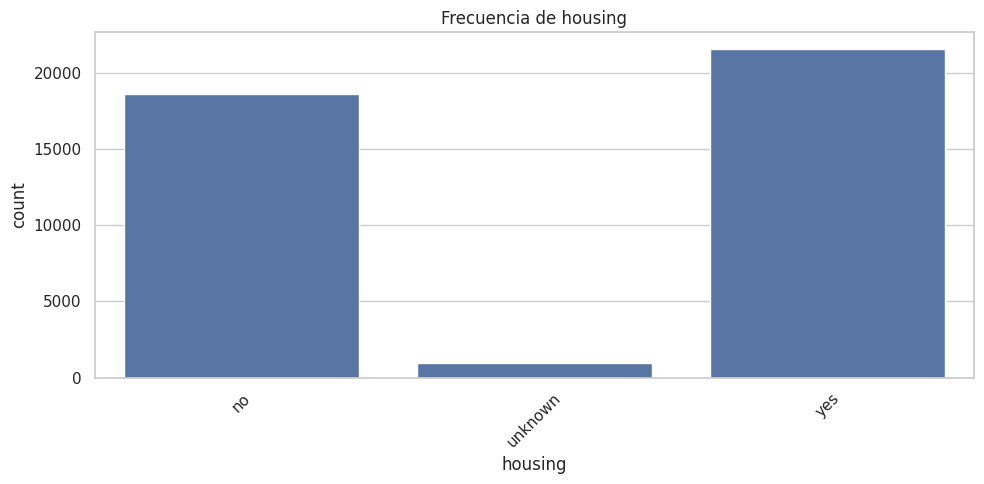

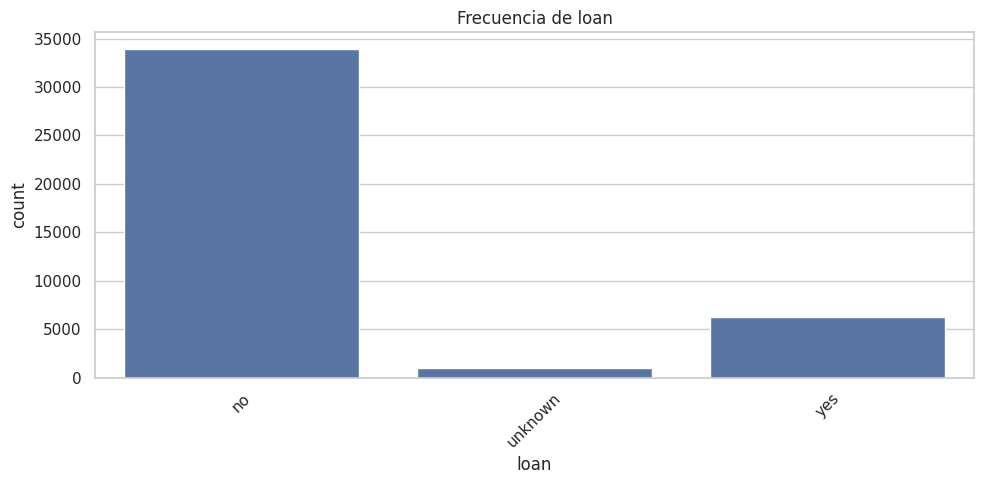

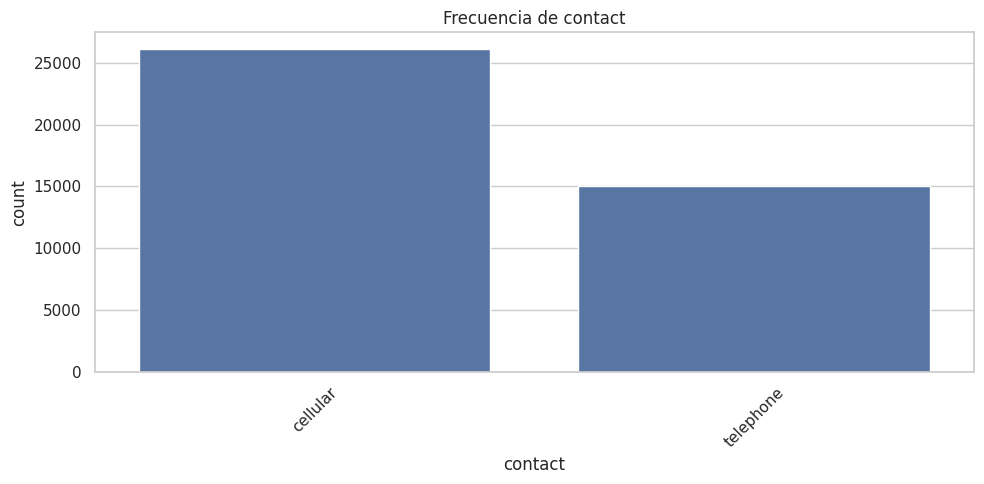

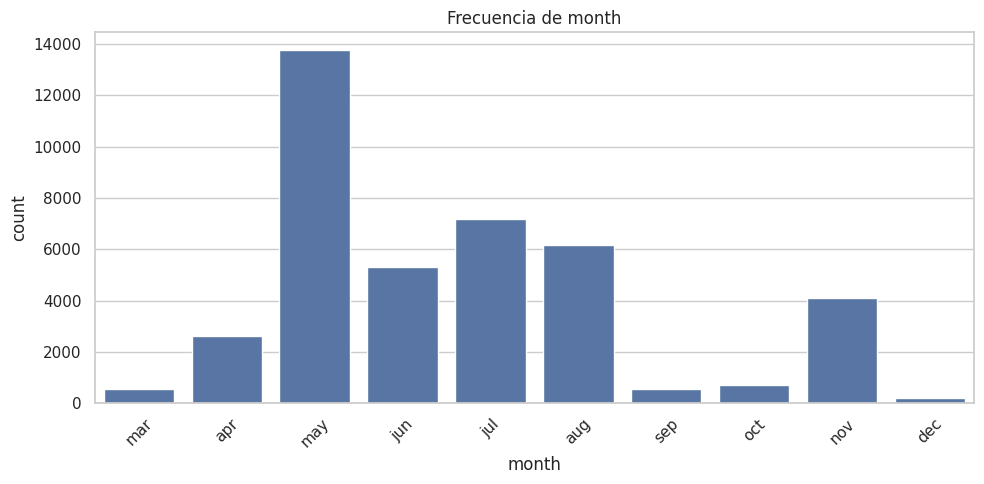

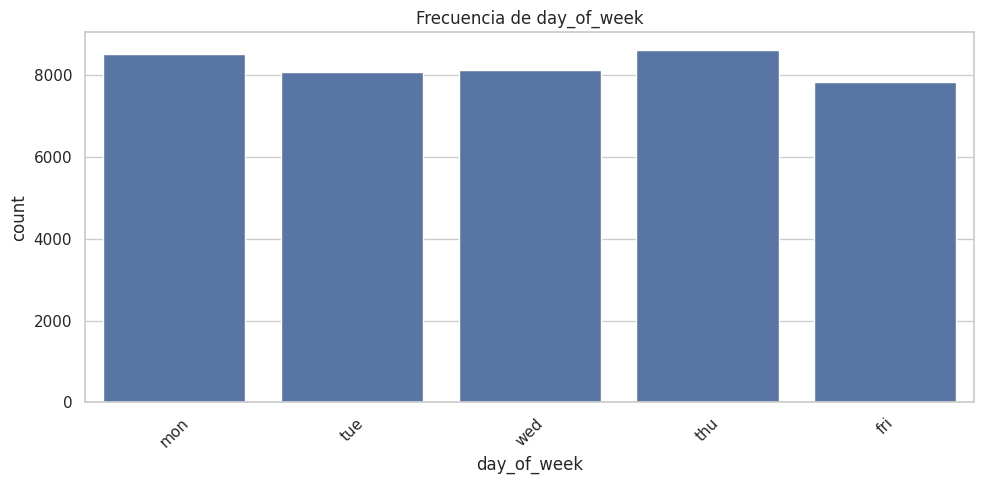

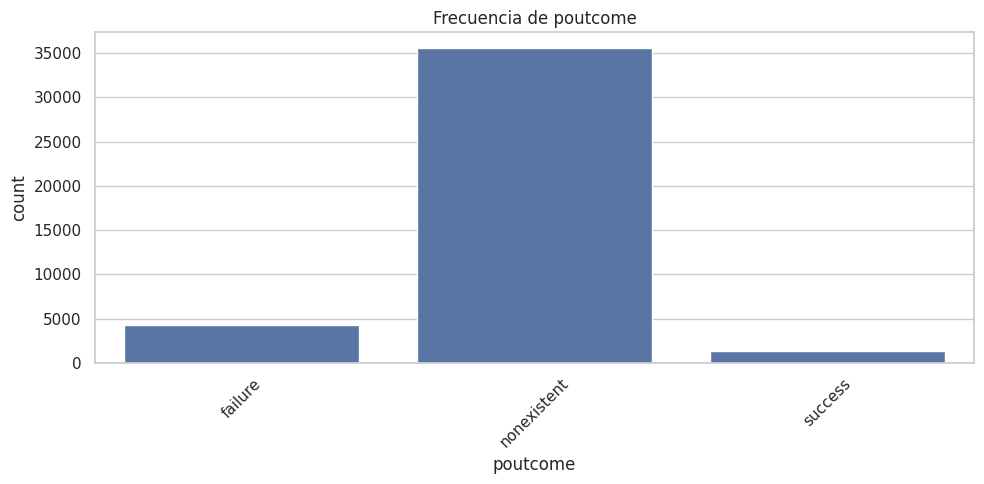

In [42]:
for column in categorical_columns:
    ordered_frame = df.copy()

    if column == "month":
        ordered_frame[column] = pd.Categorical(ordered_frame[column], categories=MONTH_ORDER, ordered=True)
    elif column == "day_of_week":
        ordered_frame[column] = pd.Categorical(ordered_frame[column], categories=DAY_ORDER, ordered=True)

    frequency_table = ordered_frame[column].value_counts(dropna=False).sort_index().reset_index()
    frequency_table.columns = [column, "count"]

    plt.figure(figsize=CATEGORY_PLOTS_FIGSIZE)
    sns.barplot(data=frequency_table, x=column, y="count")
    plt.title(f"Frecuencia de {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Tratamiento conceptual de `unknown`

En este proyecto, `unknown` se conserva por dos razones:

1. Puede representar una **señal comercial indirecta**, por ejemplo, menor calidad de captura o menor conocimiento del cliente.
2. Eliminarlo automáticamente podría introducir sesgo y pérdida de información.

Más adelante, durante la preparación del clustering, esta categoría será renombrada para que su interpretación sea explícita.

## 4.3 Análisis bivariado

El análisis bivariado tiene dos ejes principales:

- relación entre variables numéricas,
- y relación entre variables explicativas y la variable objetivo `y`.

Aunque el clustering es una técnica no supervisada, esta comparación posterior con `y` es esencial para evaluar valor de negocio.

In [43]:
target_distribution = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="proportion")
)
target_distribution["percentage"] = target_distribution["proportion"] * 100
target_distribution

,y,proportion,percentage
0,no,0.8873,88.7346
1,yes,0.1127,11.2654


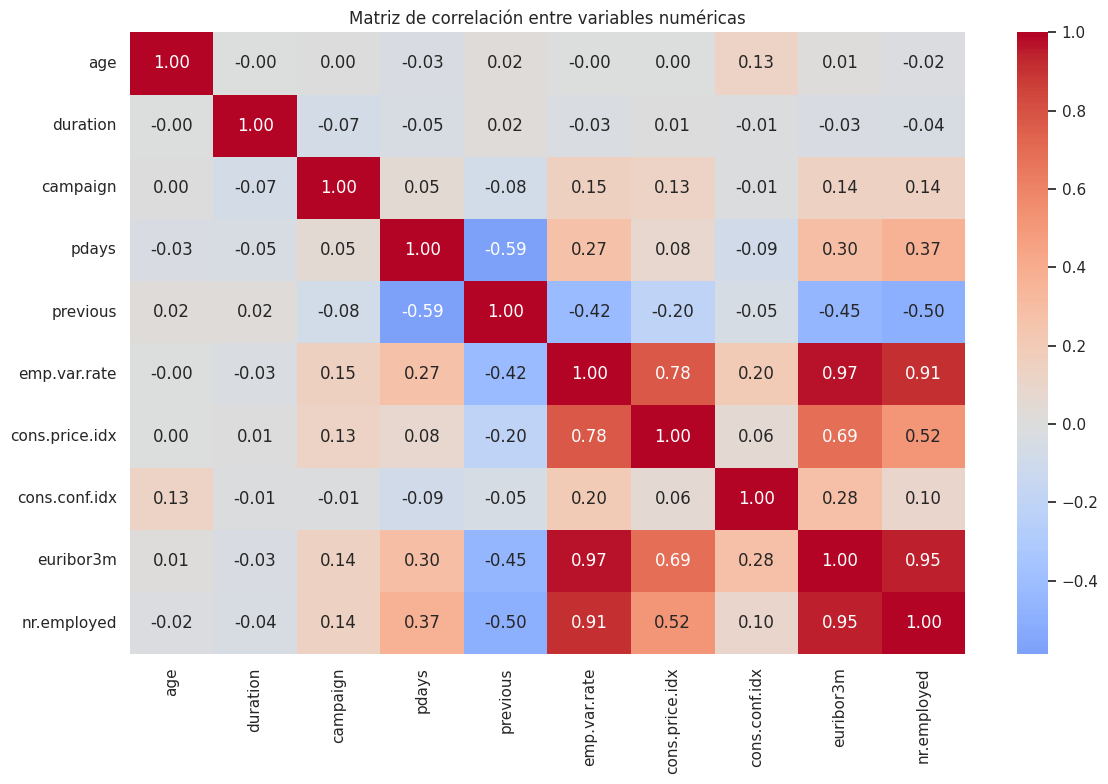

,variable_1,variable_2,correlation
1,emp.var.rate,euribor3m,0.9722
3,euribor3m,nr.employed,0.9452
2,emp.var.rate,nr.employed,0.9070
0,emp.var.rate,cons.price.idx,0.7753


In [44]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=CORRELATION_FIGSIZE)
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

redundancy_report = redundancy_pairs(correlation_matrix=correlation_matrix, threshold=0.75)
redundancy_report

In [45]:
numeric_by_target = numeric_summary_by_target(
    df,
    numeric_columns=numeric_columns,
    target_column=TARGET_COLUMN,
)
numeric_by_target

y,no,yes
age,39.9112,40.9131
duration,220.8448,553.1912
campaign,2.6331,2.0517
pdays,984.1139,792.0356
previous,0.1324,0.4927
emp.var.rate,0.2489,-1.2334
cons.price.idx,93.6038,93.3544
cons.conf.idx,-40.5931,-39.7898
euribor3m,3.8115,2.1231
nr.employed,"5,176.1666","5,095.1160"


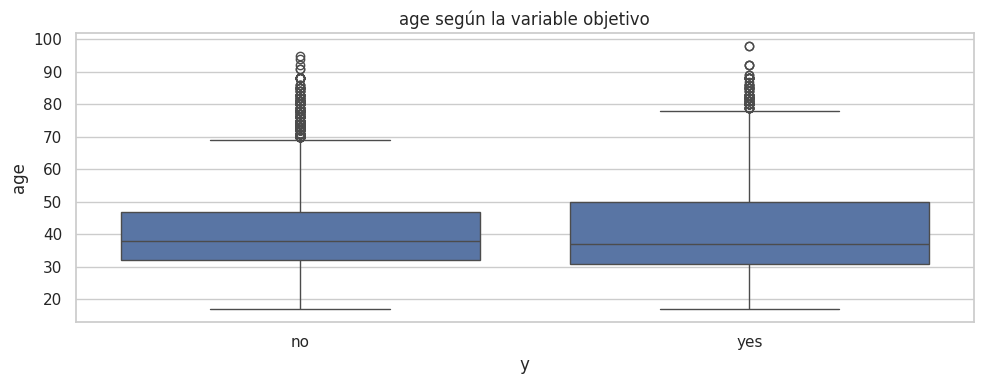

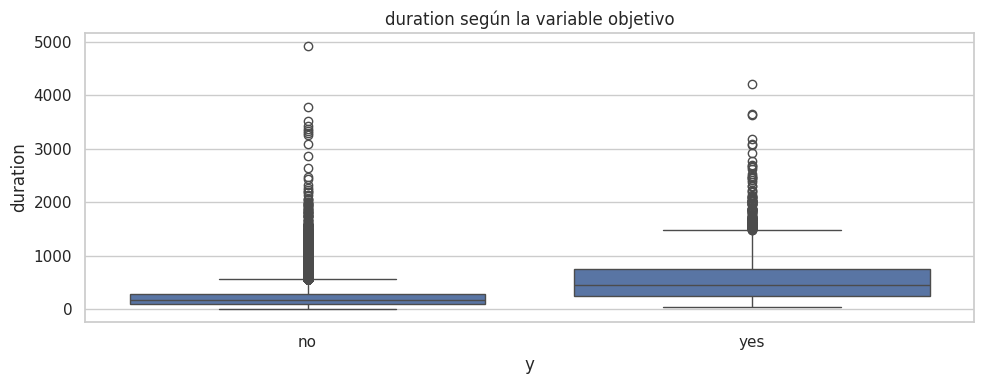

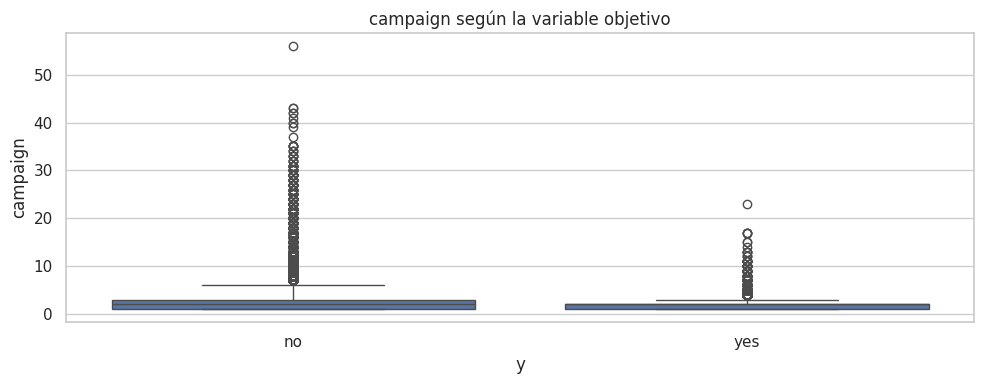

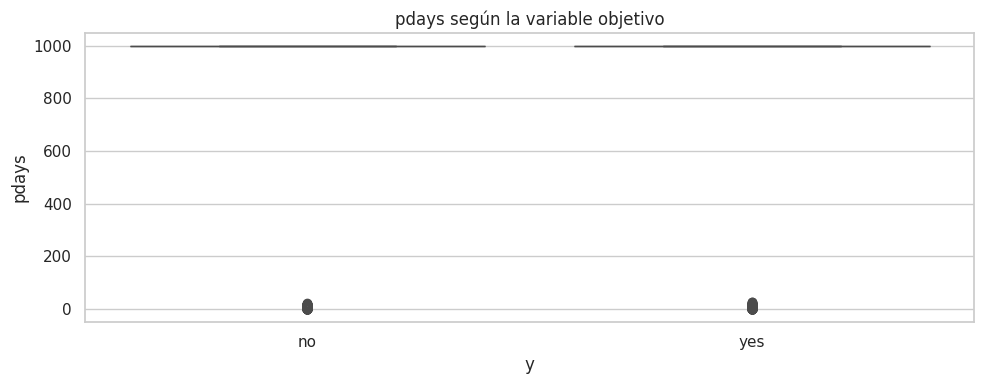

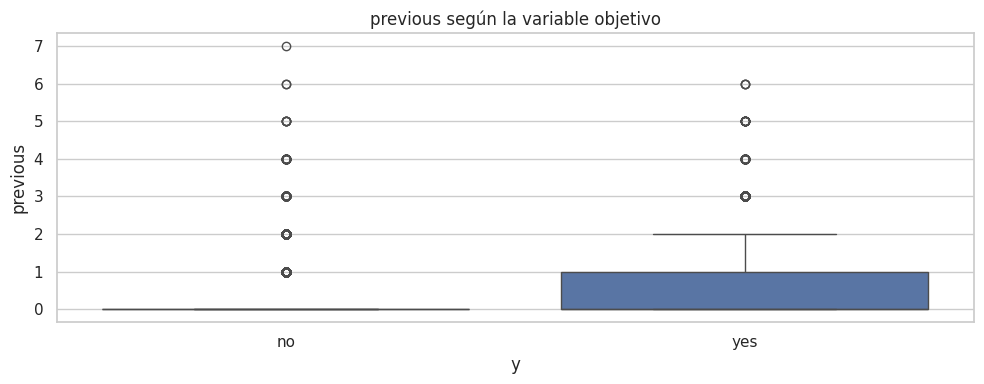

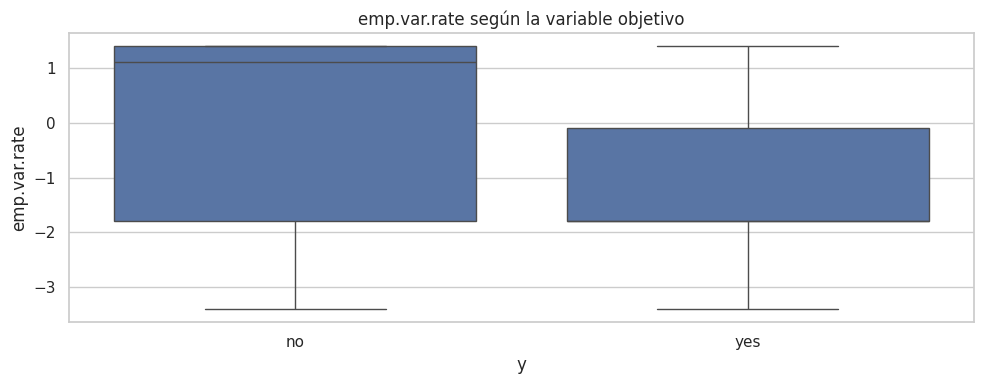

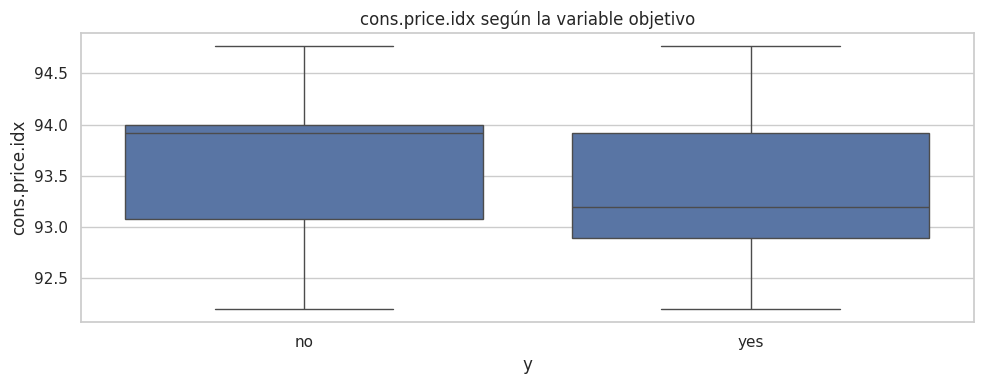

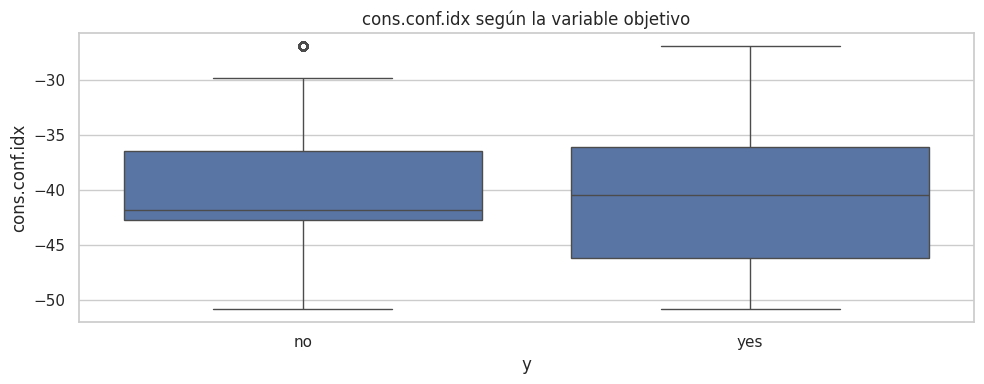

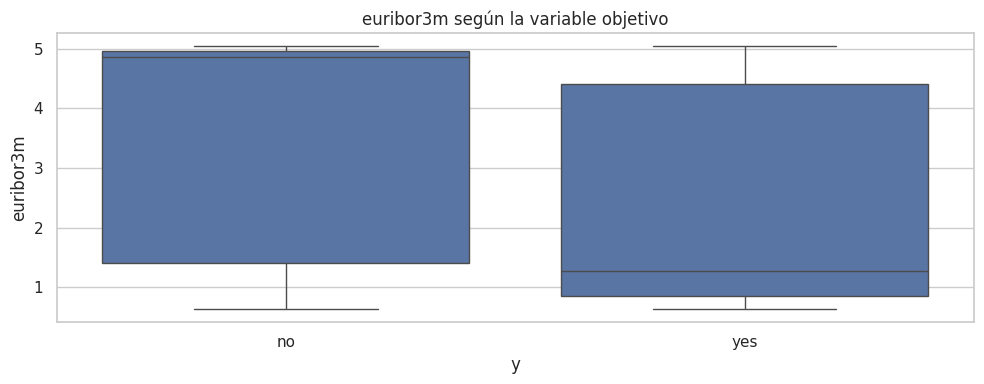

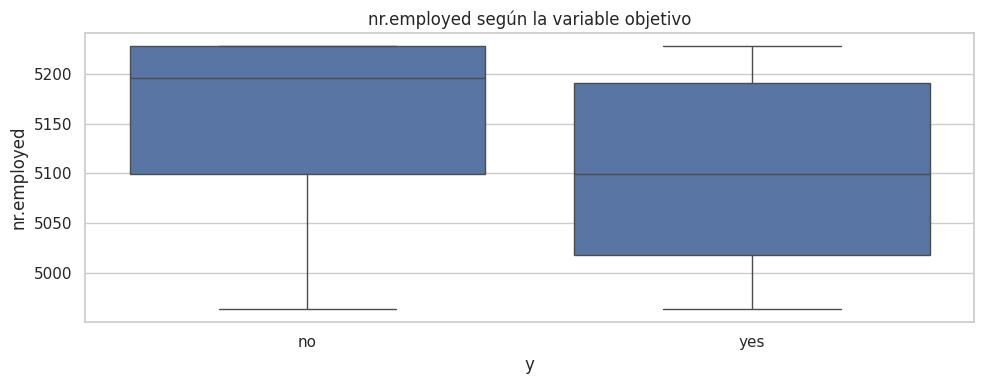

In [46]:
for column in numeric_columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=TARGET_COLUMN, y=column)
    plt.title(f"{column} según la variable objetivo")
    plt.tight_layout()
    plt.show()

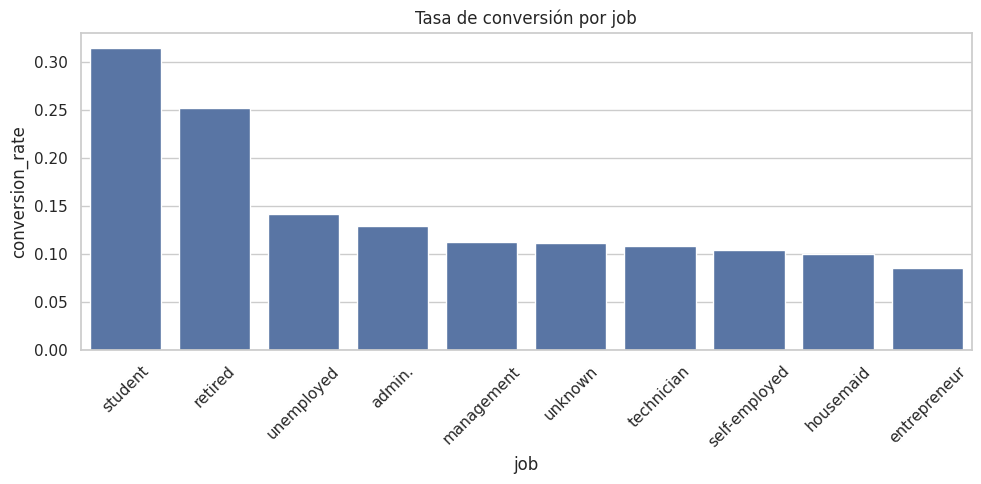

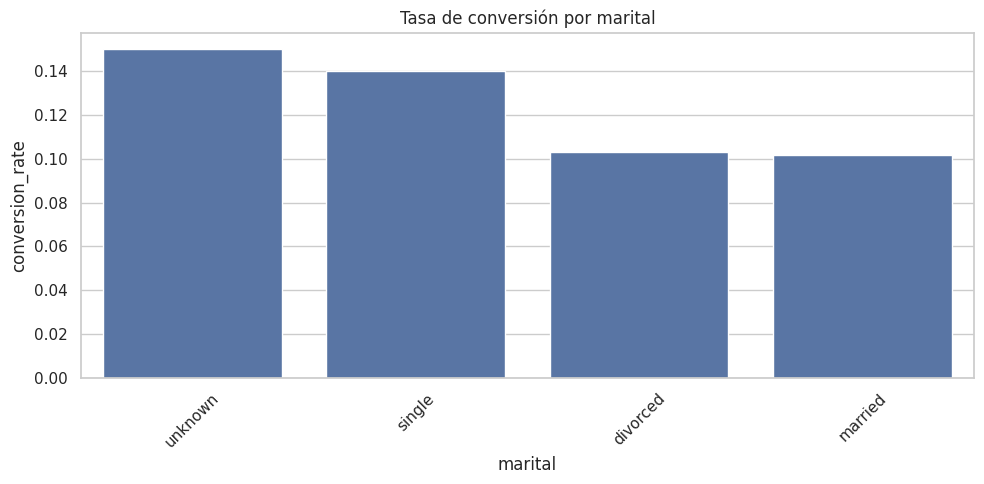

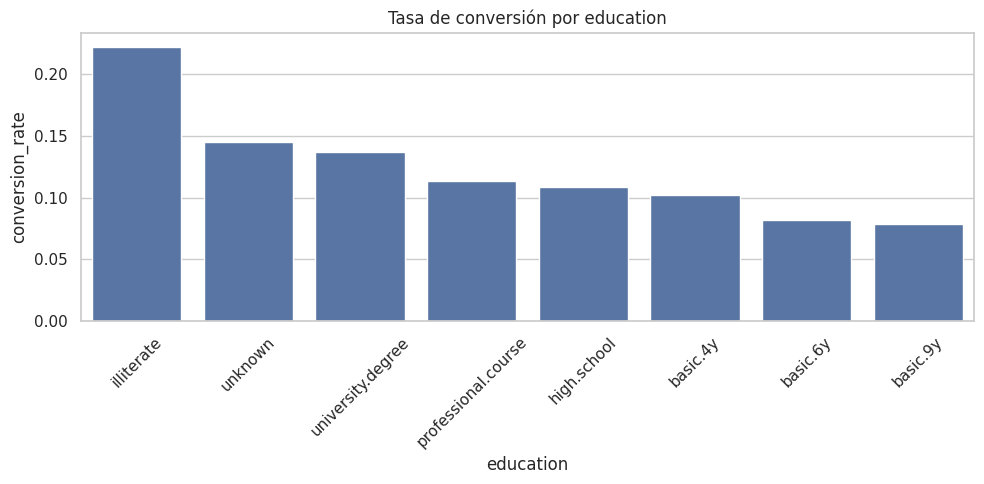

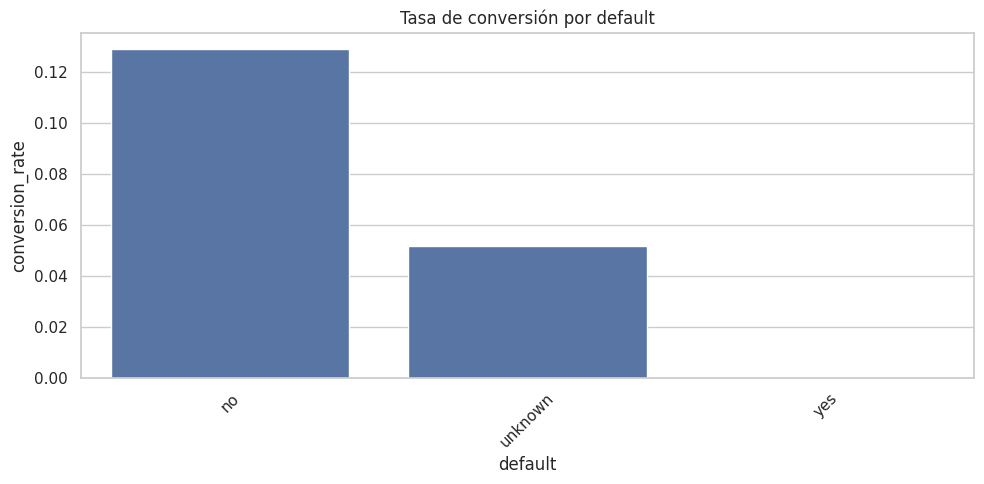

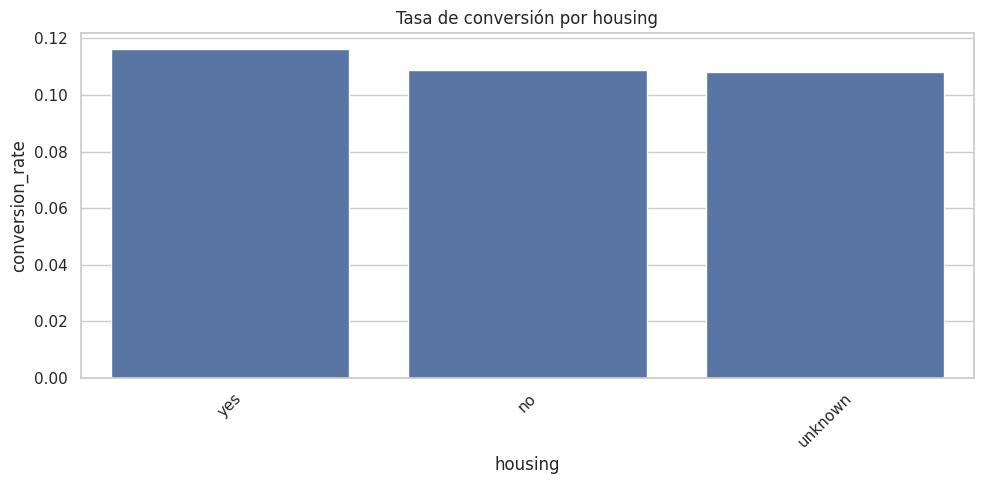

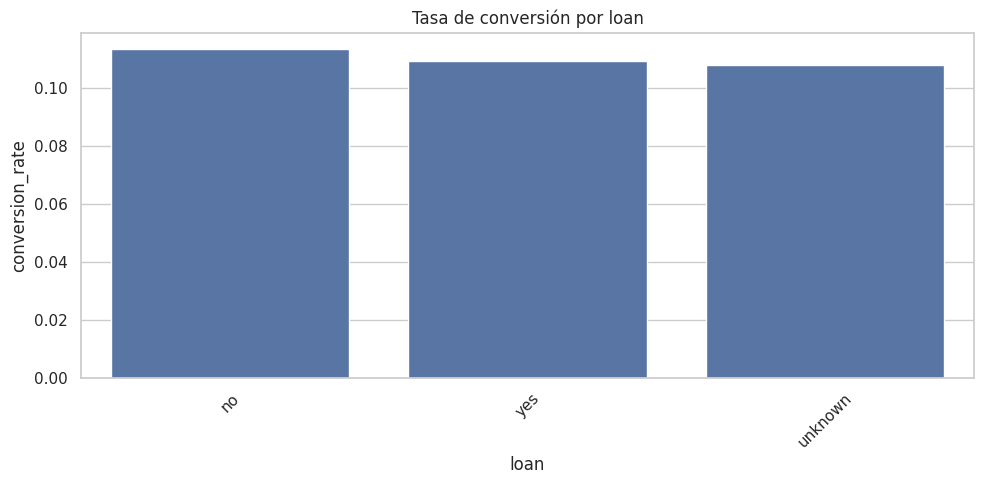

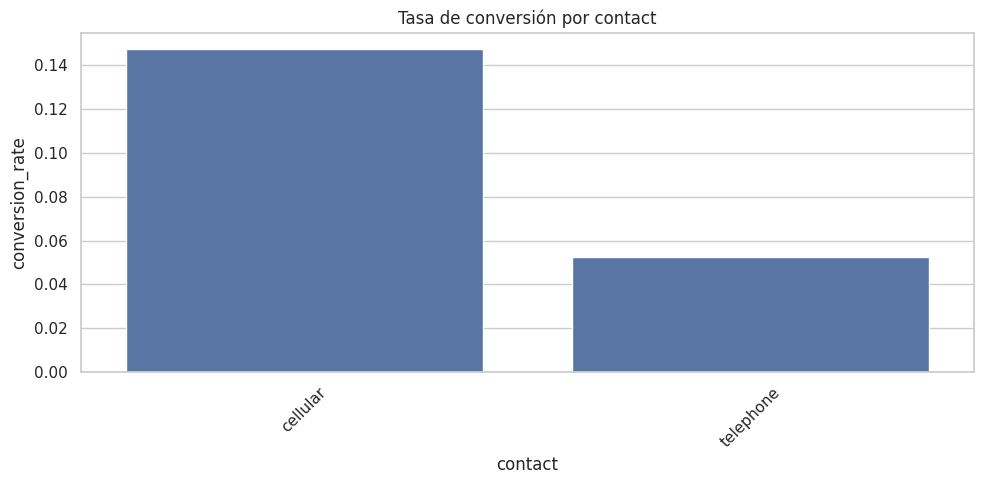

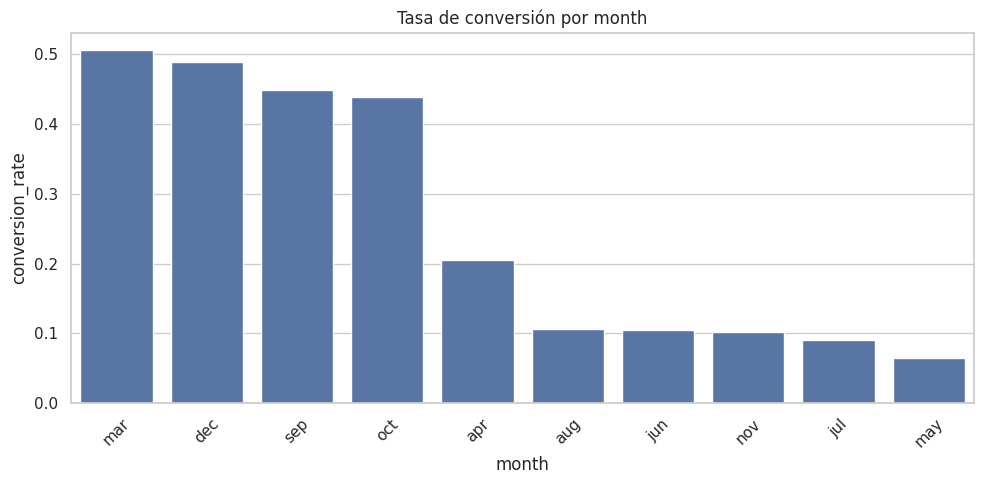

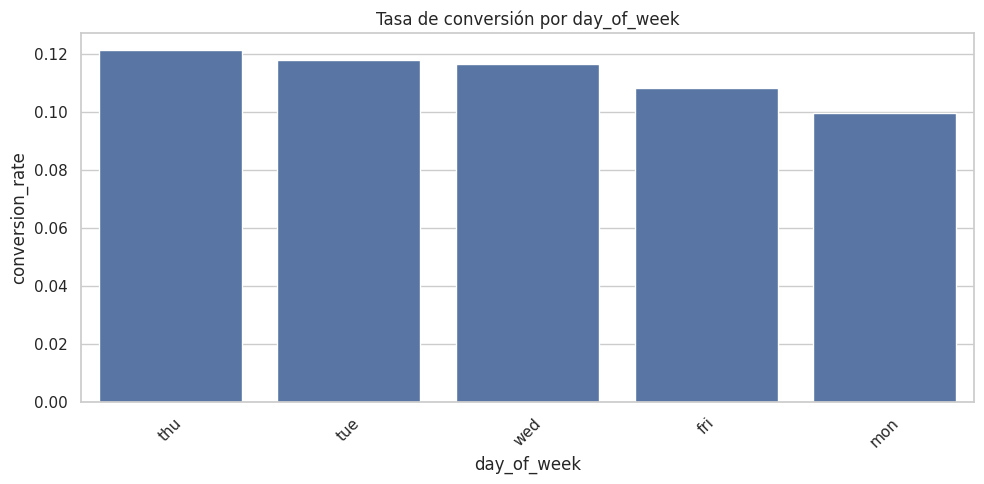

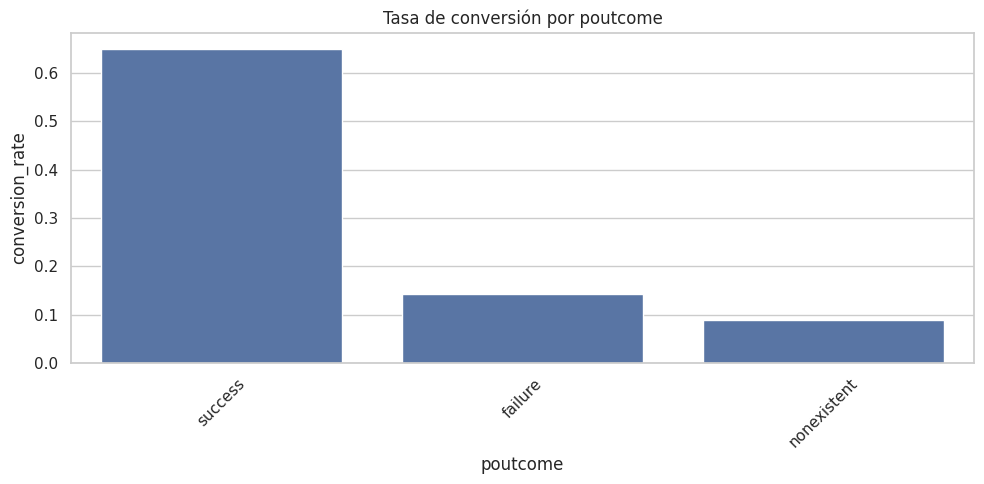

,job,records,conversions,conversion_rate
8,student,875,275,0.3143
5,retired,1720,434,0.2523
10,unemployed,1014,144,0.1420
0,admin.,10422,1352,0.1297
4,management,2924,328,0.1122
11,unknown,330,37,0.1121
9,technician,6743,730,0.1083
6,self-employed,1421,149,0.1049
3,housemaid,1060,106,0.1000
2,entrepreneur,1456,124,0.0852


In [47]:
category_target_results = {}

for column in categorical_columns:
    summary = conversion_rate_by_category(
        df,
        categorical_column=column,
        target_column=TARGET_COLUMN,
    )
    category_target_results[column] = summary

    plot_frame = summary.sort_values(by="conversion_rate", ascending=False).head(TOP_CATEGORY_LEVELS)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_frame, x=column, y="conversion_rate")
    plt.title(f"Tasa de conversión por {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

category_target_results["job"].head(10)

### Lectura analítica esperada

En esta sección deben destacarse preguntas como:

- ¿Qué categorías muestran mayor tasa de conversión?
- ¿Hay evidencia de que campañas previas exitosas (`poutcome`) se asocien con mayor propensión de conversión?
- ¿Los indicadores macroeconómicos parecen diferenciar grupos con distinta respuesta comercial?
- ¿Existen variables redundantes que podrían condensarse analíticamente?

La interpretación debe priorizar patrones accionables, no descripciones literales de cada gráfica.

## 4.4 Análisis multivariado con PCA

El PCA se utiliza con dos objetivos:

1. Reducir dimensionalidad para visualizar la estructura global del dataset.
2. Evaluar si existe redundancia estructural que concentre gran parte de la varianza en pocas componentes.

Esto no sustituye la segmentación, pero ayuda a comprender su geometría.

In [48]:
df_for_pca = build_clustering_dataset(
    df=df,
    categorical_columns=categorical_columns,
    exclude_duration=True,
    target_column=TARGET_COLUMN,
)

clustering_numeric_columns, clustering_categorical_columns = get_variable_types(
    df_for_pca.assign(dummy_target="no"),
    target_column="dummy_target",
)

features_full, preprocessor, feature_names = transform_features(
    df=df_for_pca,
    numeric_columns=clustering_numeric_columns,
    categorical_columns=clustering_categorical_columns,
)

pca_model, pca_features = fit_pca(features_full, n_components=min(10, features_full.shape[1]))

explained_variance_df = pd.DataFrame(
    {
        "component": [f"PC{i}" for i in range(1, len(pca_model.explained_variance_ratio_) + 1)],
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca_model.explained_variance_ratio_),
    }
)
explained_variance_df

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.2809,0.2809
1,PC2,0.0978,0.3787
2,PC3,0.0797,0.4584
3,PC4,0.0686,0.5270
4,PC5,0.0629,0.5899
5,PC6,0.0477,0.6376
6,PC7,0.0328,0.6704
7,PC8,0.0319,0.7023
8,PC9,0.0277,0.7300
9,PC10,0.0211,0.7511


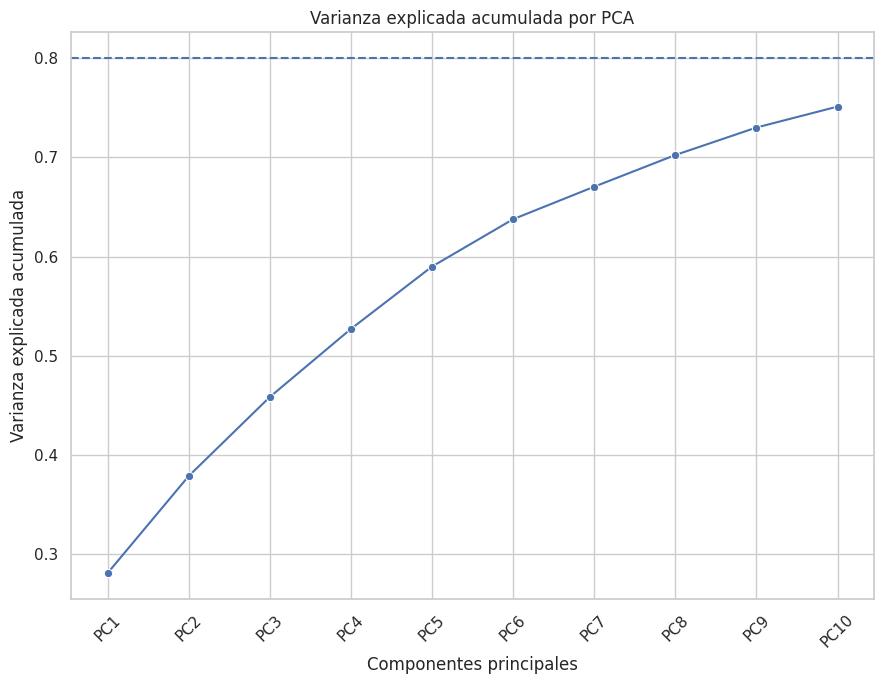

In [49]:
plt.figure(figsize=PCA_FIGSIZE)
sns.lineplot(
    data=explained_variance_df,
    x="component",
    y="cumulative_explained_variance",
    marker="o",
)
plt.axhline(0.80, linestyle="--")
plt.title("Varianza explicada acumulada por PCA")
plt.ylabel("Varianza explicada acumulada")
plt.xlabel("Componentes principales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

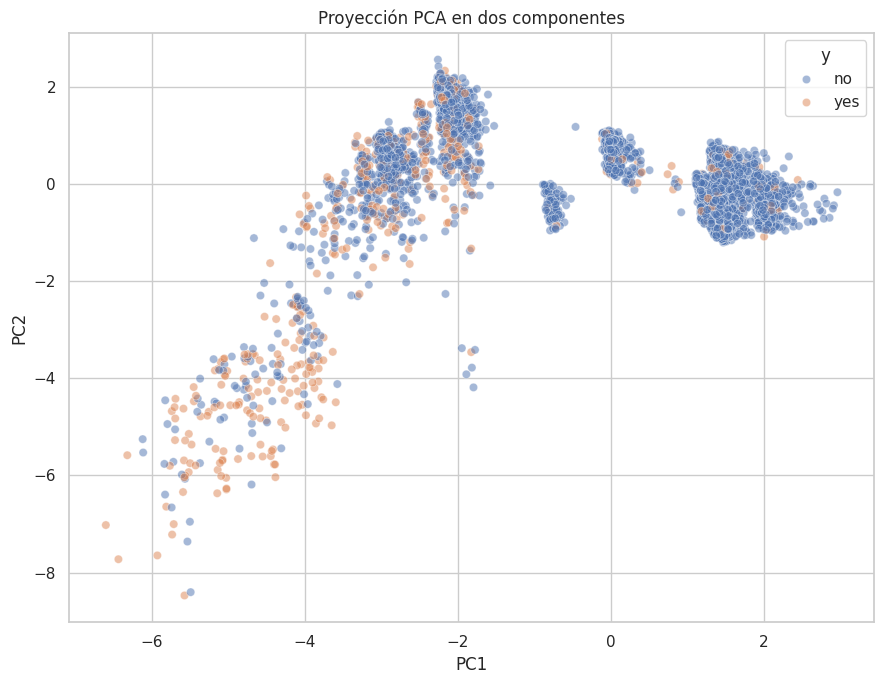

In [50]:
pca_projection = pd.DataFrame(pca_features[:, :2], columns=["PC1", "PC2"])
pca_projection[TARGET_COLUMN] = df[TARGET_COLUMN].values

plt.figure(figsize=PCA_FIGSIZE)
sns.scatterplot(
    data=pca_projection.sample(min(6000, len(pca_projection)), random_state=RANDOM_STATE),
    x="PC1",
    y="PC2",
    hue=TARGET_COLUMN,
    alpha=0.5,
)
plt.title("Proyección PCA en dos componentes")
plt.tight_layout()
plt.show()

### Interpretación sugerida del PCA

Un resultado importante aquí es determinar si la estructura del fenómeno parece:

- **altamente concentrada**, cuando pocas componentes explican gran parte de la varianza, o
- **dispersa y compleja**, cuando la varianza se distribuye en muchas dimensiones.

Esto ayuda a valorar qué tan natural o difícil será la segmentación.

## 5. Preparación de datos para clustering

En esta etapa se construye la matriz final de segmentación.  
Las decisiones técnicas son las siguientes:

- exclusión de `duration`,
- codificación one-hot para variables categóricas,
- imputación simple dentro de los pipelines,
- y escalamiento estándar para variables numéricas.

El objetivo es garantizar una representación adecuada para algoritmos basados en distancia.

In [51]:
df_model = build_clustering_dataset(
    df=df,
    categorical_columns=categorical_columns,
    exclude_duration=True,
    target_column=TARGET_COLUMN,
)

model_numeric_columns, model_categorical_columns = get_variable_types(
    df_model.assign(dummy_target="no"),
    target_column="dummy_target",
)

X, model_preprocessor, encoded_feature_names = transform_features(
    df=df_model,
    numeric_columns=model_numeric_columns,
    categorical_columns=model_categorical_columns,
)

print(f"Matriz final para clustering: {X.shape[0]:,} registros y {X.shape[1]} variables transformadas")

Matriz final para clustering: 41,188 registros y 62 variables transformadas


### Justificación técnica

Se utiliza `StandardScaler` porque tanto K-Means como Ward dependen de distancias. Sin escalamiento, variables con mayor magnitud podrían dominar artificialmente la formación de clusters.

La codificación one-hot es adecuada porque la mayoría de variables categóricas son nominales y no conviene imponerles una relación ordinal artificial.

## 6. Segmentación con K-Means

K-Means será el método base del proyecto por su eficiencia, claridad y uso extendido en segmentación comercial.  
La primera tarea consiste en seleccionar un valor de `k` técnicamente justificable.

## 6.1 Determinación del número óptimo de clusters

Se emplean dos criterios complementarios:

- **Elbow Method**, para observar la reducción marginal de inercia.
- **Silhouette Score**, para medir cohesión interna y separación entre clusters.

In [52]:
kmeans_evaluation = evaluate_kmeans_range(
    features=X,
    k_values=K_RANGE,
    random_state=RANDOM_STATE,
)
kmeans_evaluation

,k,inertia,silhouette_score
0,2,"451,714.5814",0.2863
1,3,"398,947.3130",0.2859
2,4,"372,269.0116",0.1507
3,5,"350,185.7431",0.1576
4,6,"329,459.6455",0.1612
5,7,"319,399.6244",0.1468
6,8,"301,405.5936",0.1492


In [53]:
optimal_k = select_best_k(kmeans_evaluation)
print(f"Valor sugerido por silhouette_score: k = {optimal_k}")

Valor sugerido por silhouette_score: k = 2


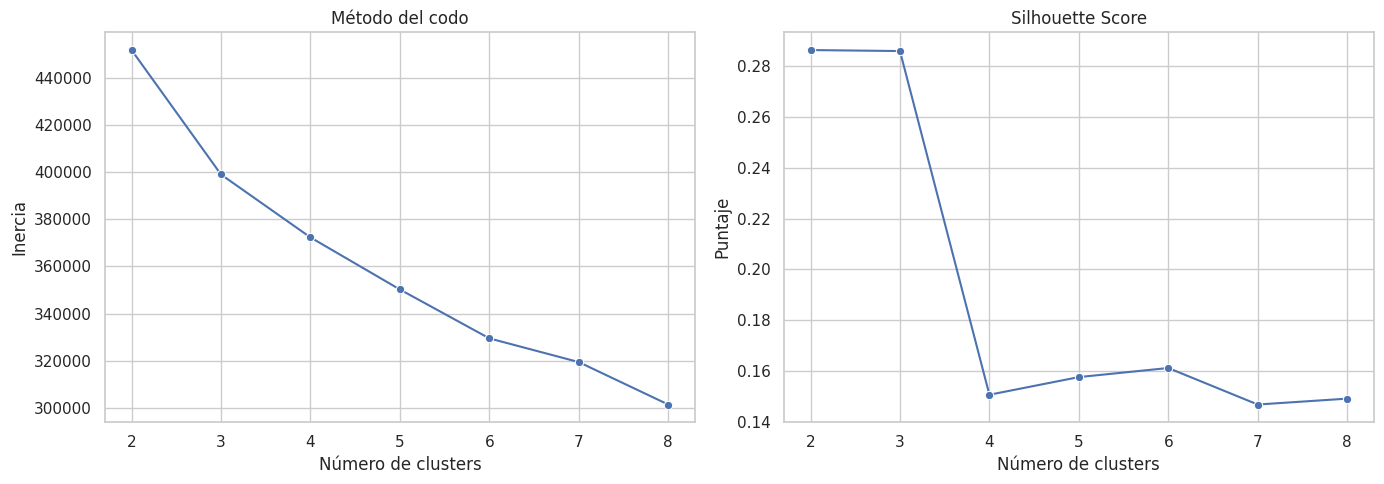

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=kmeans_evaluation, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters")
axes[0].set_ylabel("Inercia")

sns.lineplot(data=kmeans_evaluation, x="k", y="silhouette_score", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clusters")
axes[1].set_ylabel("Puntaje")

plt.tight_layout()
plt.show()

### Criterio de decisión

Cuando ambos criterios no coinciden exactamente, la elección final debe balancear tres elementos:

1. calidad geométrica del agrupamiento,
2. estabilidad práctica,
3. interpretabilidad para negocio.

Un número excesivo de clusters puede mejorar ligeramente la métrica pero empeorar la utilidad ejecutiva del modelo.

## 6.2 Entrenamiento y evaluación de K-Means

In [55]:
kmeans_model, kmeans_labels = fit_kmeans(
    features=X,
    n_clusters=optimal_k,
    random_state=RANDOM_STATE,
)

kmeans_cluster_quality = silhouette_score(
    X,
    kmeans_labels,
    sample_size=min(10000, len(X)),
    random_state=RANDOM_STATE,
)
print(f"Silhouette Score final de K-Means: {kmeans_cluster_quality:.4f}")

Silhouette Score final de K-Means: 0.2863


In [56]:
kmeans_profiles = cluster_profile(
    df_original=df,
    labels=kmeans_labels,
    numeric_columns=numeric_columns,
    categorical_columns=categorical_columns,
    target_column=TARGET_COLUMN,
)

print("Tamaño de clusters")
display(kmeans_profiles["size_table"])

print("Perfil numérico por cluster")
display(kmeans_profiles["numeric_profile"])

print("Conversión por cluster")
display(kmeans_profiles["target_profile"])

print("Moda categórica por cluster")
display(kmeans_profiles["categorical_profile"])

Tamaño de clusters


,cluster,records,share
0,0,27653,0.6714
1,1,13535,0.3286


Perfil numérico por cluster


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
cluster,,,,,,,,,,
0,40.1940,252.3540,2.8000,999.0000,0.0250,1.1170,93.8440,-39.4590,4.8180,"5,213.4090"
1,39.6770,270.4020,2.0920,887.8530,0.4750,-2.0340,93.0280,-42.6360,1.1760,"5,072.2920"


Conversión por cluster


,total,conversions,conversion_rate
cluster,,,
0,27653,1336,0.0483
1,13535,3304,0.2441


Moda categórica por cluster


,job_mode,marital_mode,education_mode,default_mode,housing_mode,loan_mode,contact_mode,month_mode,day_of_week_mode,poutcome_mode
cluster,,,,,,,,,,
0,admin.,married,university.degree,no,yes,no,cellular,may,wed,nonexistent
1,admin.,married,university.degree,no,yes,no,cellular,may,mon,nonexistent


In [57]:
kmeans_segment_names = business_segment_name(kmeans_profiles["target_profile"])
kmeans_segment_names

,total,conversions,conversion_rate,strategic_name
cluster,,,,
0,27653,1336,0.0483,Low Response Efficiency Segment
1,13535,3304,0.2441,Selective Opportunity Segment


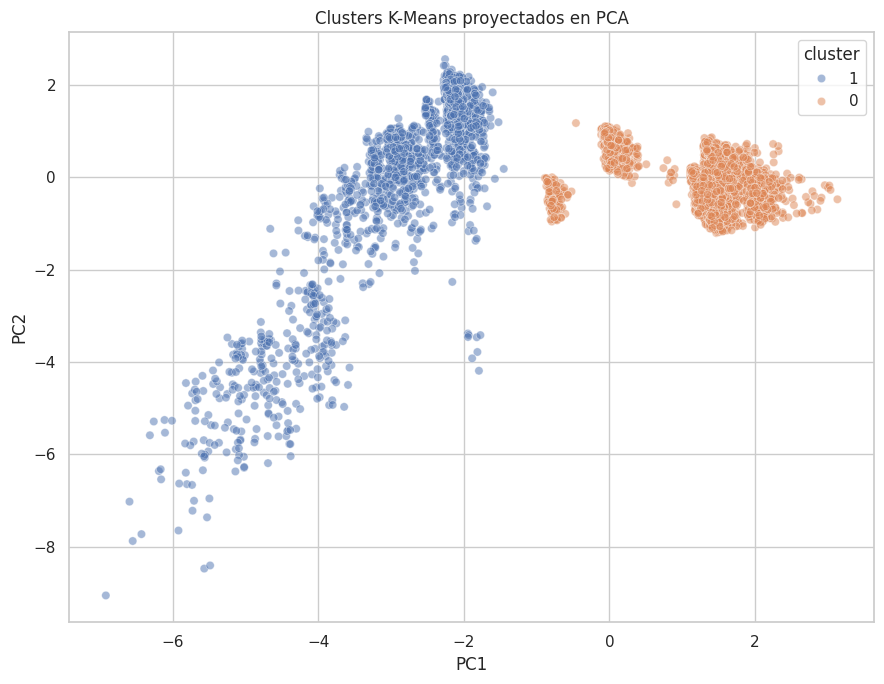

In [58]:
kmeans_plot_frame = pd.DataFrame(pca_features[:, :2], columns=["PC1", "PC2"])
kmeans_plot_frame["cluster"] = kmeans_labels.astype(str)

plt.figure(figsize=PCA_FIGSIZE)
sns.scatterplot(
    data=kmeans_plot_frame.sample(min(8000, len(kmeans_plot_frame)), random_state=RANDOM_STATE),
    x="PC1",
    y="PC2",
    hue="cluster",
    alpha=0.5,
)
plt.title("Clusters K-Means proyectados en PCA")
plt.tight_layout()
plt.show()

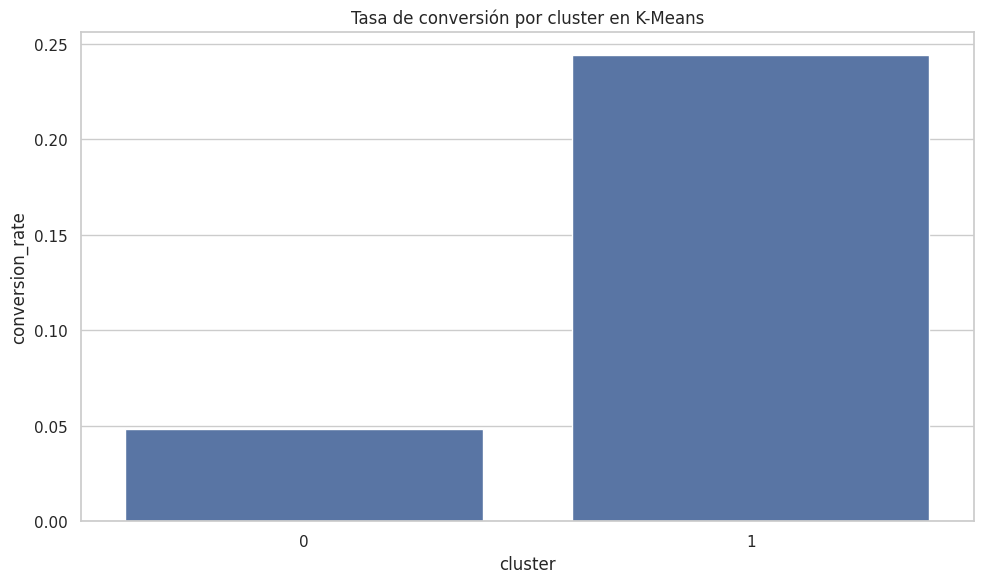

In [59]:
plt.figure(figsize=CLUSTER_PLOTS_FIGSIZE)
cluster_conversion = kmeans_profiles["target_profile"].reset_index()
sns.barplot(data=cluster_conversion, x="cluster", y="conversion_rate")
plt.title("Tasa de conversión por cluster en K-Means")
plt.tight_layout()
plt.show()

## 6.3 Guía de interpretación de clusters K-Means

Para cada cluster conviene documentar de forma explícita:

- **Perfil demográfico:** edad, ocupación, estado civil, educación.
- **Perfil financiero:** créditos de vivienda, préstamos personales, situación de default.
- **Perfil comercial:** contacto, historial de campañas, resultado previo.
- **Entorno económico:** promedios de indicadores macroeconómicos.
- **Valor comercial:** tasa de conversión `y = yes`.
- **Nombre estratégico del segmento:** etiqueta ejecutiva clara y accionable.

Esta parte debe convertirse después en narrativa del informe ejecutivo.

## 7. Segundo método: Clustering Jerárquico con enlace Ward

El segundo enfoque busca contrastar la estructura encontrada por K-Means.  
Se selecciona **Ward** porque minimiza la varianza intracluster en cada fusión y suele ser una referencia sólida para comparación estructural.

### Consideración computacional

El clustering jerárquico es más costoso que K-Means. Para mantener viabilidad en un entorno académico y local, se trabajará con una muestra controlada para el dendrograma y la comparación estructural.

In [60]:
hierarchical_indices = (
    pd.Series(np.arange(len(X)))
    .sample(min(HIERARCHICAL_SAMPLE_SIZE, len(X)), random_state=RANDOM_STATE)
    .sort_values()
    .to_numpy()
)
X_hierarchical = X[hierarchical_indices]
df_hierarchical = df.iloc[hierarchical_indices].copy()

print(f"Muestra usada para clustering jerárquico: {X_hierarchical.shape[0]:,} registros")

Muestra usada para clustering jerárquico: 3,000 registros


In [61]:
hierarchical_pca_model, hierarchical_pca_features = fit_pca(
    X_hierarchical,
    n_components=min(PCA_COMPONENTS_FOR_CLUSTERING, X_hierarchical.shape[1]),
)

hierarchical_model, hierarchical_labels = fit_hierarchical(
    features=hierarchical_pca_features,
    n_clusters=optimal_k,
    linkage_method="ward",
)

hierarchical_silhouette = silhouette_score(
    hierarchical_pca_features,
    hierarchical_labels,
)
print(f"Silhouette Score del clustering jerárquico: {hierarchical_silhouette:.4f}")

Silhouette Score del clustering jerárquico: 0.3793


In [62]:
hierarchical_profiles = cluster_profile(
    df_original=df_hierarchical,
    labels=hierarchical_labels,
    numeric_columns=numeric_columns,
    categorical_columns=categorical_columns,
    target_column=TARGET_COLUMN,
)

print("Tamaño de clusters")
display(hierarchical_profiles["size_table"])

print("Perfil numérico por cluster")
display(hierarchical_profiles["numeric_profile"])

print("Conversión por cluster")
display(hierarchical_profiles["target_profile"])

print("Moda categórica por cluster")
display(hierarchical_profiles["categorical_profile"])

Tamaño de clusters


,cluster,records,share
0,0,990,0.3300
1,1,2010,0.6700


Perfil numérico por cluster


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
cluster,,,,,,,,,,
0,39.6830,269.9540,2.1280,869.5900,0.4940,-2.0250,93.0280,-42.5350,1.1810,"5,072.4980"
1,39.8090,259.6600,2.7460,999.0000,0.0260,1.1170,93.8480,-39.4520,4.8190,"5,213.1290"


Conversión por cluster


,total,conversions,conversion_rate
cluster,,,
0,990,246,0.2485
1,2010,101,0.0502


Moda categórica por cluster


,job_mode,marital_mode,education_mode,default_mode,housing_mode,loan_mode,contact_mode,month_mode,day_of_week_mode,poutcome_mode
cluster,,,,,,,,,,
0,admin.,married,university.degree,no,yes,no,cellular,may,mon,nonexistent
1,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent


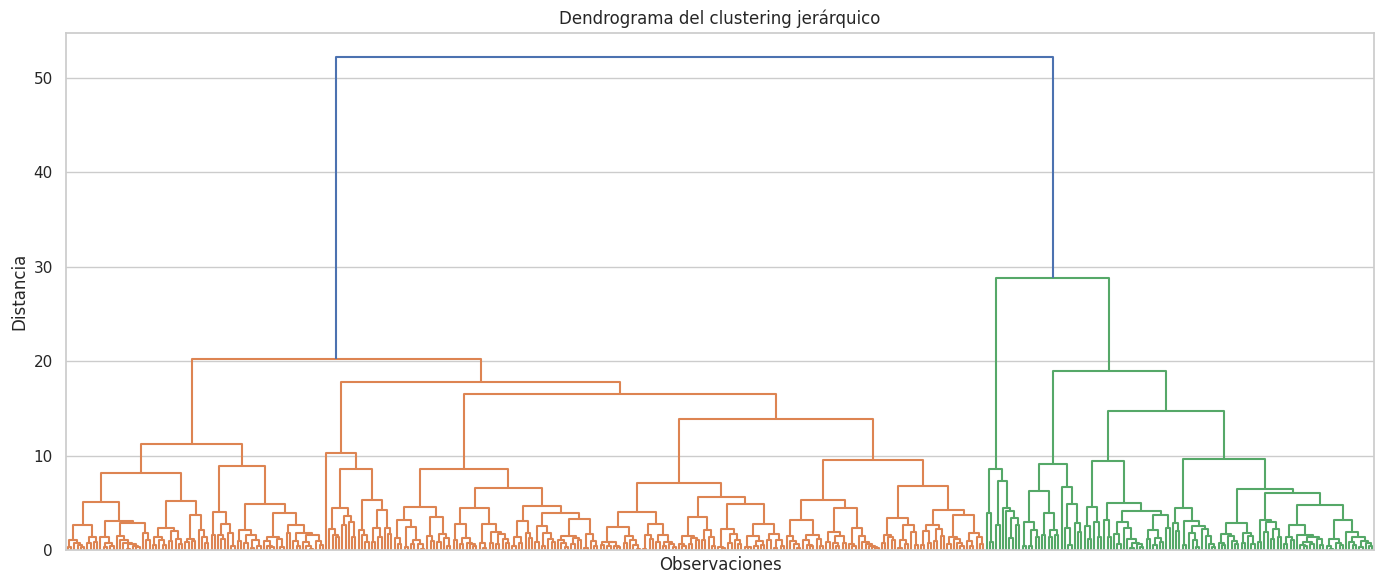

In [63]:
dendrogram_indices = (
    pd.Series(np.arange(len(X_hierarchical)))
    .sample(min(DENDROGRAM_SAMPLE_SIZE, len(X_hierarchical)), random_state=RANDOM_STATE)
    .sort_values()
    .to_numpy()
)
X_dendrogram = hierarchical_pca_features[dendrogram_indices]

linkage_matrix = hierarchical_linkage_matrix(X_dendrogram, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode=None, color_threshold=None, no_labels=True)
plt.title("Dendrograma del clustering jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

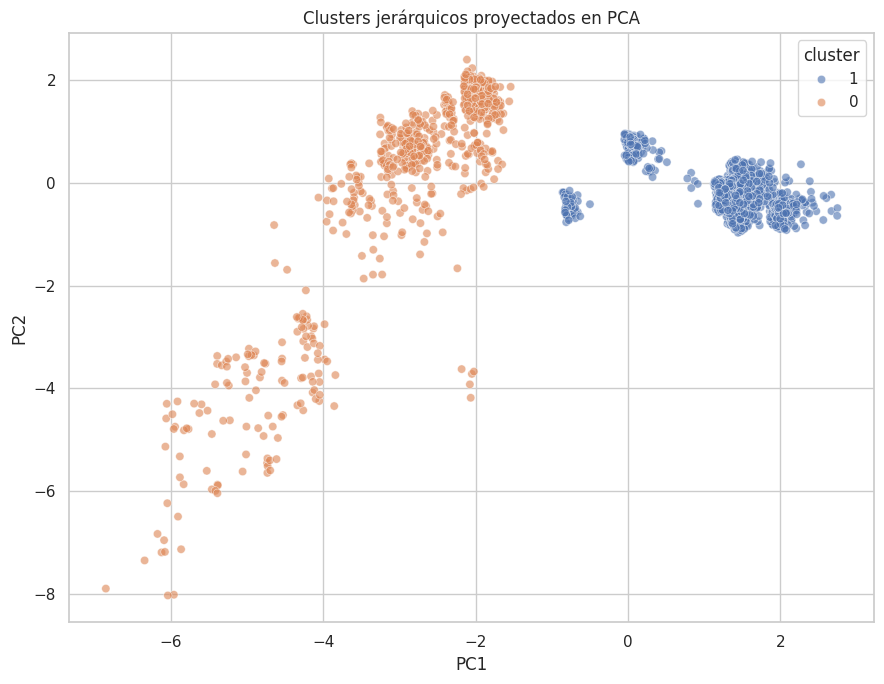

In [64]:
hierarchical_plot_frame = pd.DataFrame(hierarchical_pca_features[:, :2], columns=["PC1", "PC2"])
hierarchical_plot_frame["cluster"] = hierarchical_labels.astype(str)

plt.figure(figsize=PCA_FIGSIZE)
sns.scatterplot(
    data=hierarchical_plot_frame,
    x="PC1",
    y="PC2",
    hue="cluster",
    alpha=0.6,
)
plt.title("Clusters jerárquicos proyectados en PCA")
plt.tight_layout()
plt.show()

### Lectura esperada del método jerárquico

Este método resulta especialmente útil para:

- observar si existen cortes relativamente naturales en el dendrograma,
- validar si la estructura de segmentos se asemeja o no a K-Means,
- y enriquecer la interpretación de negocio desde una perspectiva estructural.

## 8. Comparación formal entre métodos

La comparación no debe limitarse a la métrica. También debe considerar supuestos, sensibilidad, costo computacional e interpretabilidad.

In [65]:
comparison_table = pd.DataFrame(
    {
        "Criterio": [
            "Supuestos",
            "Sensibilidad a outliers",
            "Escalabilidad",
            "Interpretabilidad",
            "Calidad del cluster",
        ],
        "K-Means": [
            "Asume clusters compactos y aproximadamente esféricos con distancia euclidiana.",
            "Alta; los centroides pueden desplazarse por valores extremos.",
            "Alta; es adecuado para volúmenes grandes.",
            "Alta si el número de clusters es razonable y el perfil es claro.",
            f"Silhouette Score = {kmeans_cluster_quality:.4f}",
        ],
        "Clustering Jerárquico": [
            "No requiere centroides; construye estructura por fusiones sucesivas.",
            "Media a alta, según la distancia y el método de enlace.",
            "Menor; el costo computacional crece rápidamente con el volumen.",
            "Muy alta por el apoyo visual del dendrograma.",
            f"Silhouette Score = {hierarchical_silhouette:.4f}",
        ],
    }
)
comparison_table

,Criterio,K-Means,Clustering Jerárquico
0,Supuestos,Asume clusters compactos y aproximadamente esf...,No requiere centroides; construye estructura p...
1,Sensibilidad a outliers,Alta; los centroides pueden desplazarse por va...,"Media a alta, según la distancia y el método d..."
2,Escalabilidad,Alta; es adecuado para volúmenes grandes.,Menor; el costo computacional crece rápidament...
3,Interpretabilidad,Alta si el número de clusters es razonable y e...,Muy alta por el apoyo visual del dendrograma.
4,Calidad del cluster,Silhouette Score = 0.2863,Silhouette Score = 0.3793


La evidencia estadística y visual respalda una segmentación en **k = 2**. En K-Means, este valor obtuvo el mejor `silhouette_score` (**0.2863**) y mantuvo una estructura simple e interpretable. Además, en la proyección PCA los clusters se observan bien separados.

El clustering jerárquico confirmó esta estructura. Su `silhouette_score` fue mayor (**0.3793**) y el dendrograma mostró que el corte en **k = 2** es natural, aunque `k = 3` podría considerarse una alternativa secundaria. Aun así, desde una perspectiva operativa, **K-Means resulta más conveniente como método principal** por su escalabilidad y facilidad de implementación sobre el dataset completo, mientras que el método jerárquico aporta valor como herramienta de validación estructural.

## 9. Hallazgos estratégicos por segmento

### Cluster 0: baja respuesta y baja vinculación previa

Este cluster concentra el **67.14 %** de los clientes y presenta una tasa de conversión de apenas **4.83 %**, por lo que representa el segmento menos eficiente para campañas telefónicas. Su comportamiento se caracteriza por **muy baja interacción previa**, reflejada en `pdays = 999` y `previous = 0.025` en promedio. Además, presenta mayor presión comercial, con más contactos promedio por campaña.

Desde negocio, este segmento puede interpretarse como un grupo de **baja afinidad comercial inmediata**. La recomendación es no priorizarlo en campañas intensivas, sino usar estrategias de menor costo o filtros adicionales antes de asignar esfuerzo comercial directo.

### Cluster 1: oportunidad comercial con mayor probabilidad de conversión

Este cluster representa el **32.86 %** de los clientes, pero alcanza una tasa de conversión de **24.41 %**, muy superior a la del Cluster 0. Se distingue por un **mayor historial de contacto previo**, con menor `pdays` y mayor valor promedio de `previous`, lo que sugiere una relación comercial más madura y una mejor predisposición a responder.

Desde negocio, este es el segmento más valioso para campañas de depósitos a plazo. La recomendación es **priorizarlo** en acciones telefónicas, seguimiento comercial y ofertas dirigidas, ya que concentra la mejor probabilidad de conversión con menor esfuerzo relativo.

## 10. Conclusiones técnicas del notebook

El análisis permitió identificar **dos segmentos principales de clientes**, consistentes tanto en K-Means como en clustering jerárquico. Esta coincidencia fortalece la validez de la segmentación obtenida.

No se encontraron valores nulos explícitos en el dataset, pero sí se detectaron outliers importantes en variables como `previous`, `pdays`, `campaign` y `duration`, los cuales responden en buena medida a la lógica del negocio y no deben interpretarse automáticamente como errores. También se observó una fuerte redundancia entre variables económicas, especialmente `emp.var.rate`, `euribor3m` y `nr.employed`.

La exclusión de `duration` fue metodológicamente correcta, ya que introduce información que no estaría disponible antes de la llamada. En conjunto, los resultados muestran que la segmentación sí aporta valor de negocio, al separar claramente un grupo de **baja respuesta** de otro con **alto potencial comercial**.

## 11. Referencias

- Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing*. Decision Support Systems.
- Tan, P. N., Steinbach, M., & Kumar, V. (2019). *Introduction to Data Mining* (2nd ed.). Pearson.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
- UCI Machine Learning Repository. *Bank Marketing Dataset*.
- Documentación oficial de scikit-learn para `KMeans`, `silhouette_score`, `PCA`, `OneHotEncoder`, `ColumnTransformer` y `AgglomerativeClustering`.